## 1 - Importando pacotes e bibliotecas

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.tseries.offsets import Week

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller


from statsmodels.api import OLS, add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor


from pathlib import Path

REPOSITORY_PATH = Path('study.ipynb').resolve().parents[2]

### 1.1 - Funções de Suporte

In [133]:
def pct_active(series):
    # Calcula o percentual de semanas ativas
    return (series > 0).mean()

def coeff_variation(series):
    # Calcula o coeficiente de variação considerando apenas as semanas ativas
    series = series[series > 0]
    if len(series) == 0:
        return np.nan
    return series.std() / series.mean()

def count_bursts(series):
    # Calcula a quantidade de "bursts" ou períodos apartados de atividade
    active = series > 0
    return ((active != active.shift(1)) & active).sum()

## 2 - Carregando dataframe de estudo

| Coluna | Tipo | Descrição |
| :--- | :--- | :--- |
| **date** | string | Data de início da semana (YYYY-MM-DD) |
| **units_sold** | int | Unidades vendidas na semana |
| **revenue_brl** | float | Receita bruta em R$ |
| **avg_price_brl** | float | Preço médio ponderado por unidade vendida (R$) |
| **tv_spend_brl** | float | Investimento em TV aberta e streaming (R$) |
| **google_search_spend_brl** | float | Investimento em Google Search Ads (R$) |
| **google_display_spend_brl** | float | Investimento em Google Display Network (R$) |
| **meta_spend_brl** | float | Investimento em Meta Ads - Facebook + Instagram (R$) |
| **ooh_spend_brl** | float | Investimento em Out-of-Home - painéis, busdoor, mídia exterior (R$) |
| **email_crm_sends** | int | Volume de e-mails enviados via CRM na semana |
| **influencer_spend_brl** | float | Investimento em campanhas com influenciadores (R$) |
| **leads_generated** | int | Leads capturados via formulários e landing pages |
| **website_sessions** | int | Total de sessões no site na semana |
| **coupons_redeemed** | int | Cupons de desconto resgatados na semana |
| **affiliate_commission_brl** | float | Comissão total paga ao programa de afiliados (R$) |
| **competitor_promo_index** | float | Índice de intensidade promocional dos concorrentes (0 a 1) |
| **economic_confidence_index** | float | Índice de confiança do consumidor (normalizado) |
| **is_black_friday** | int | Semana de Black Friday - 1 ou 0 |
| **holiday_week** | int | Semana com feriado nacional de alto impacto no varejo - 1 ou 0 |

In [134]:
df = pd.read_csv(f'{REPOSITORY_PATH}/varejo360/data/raw/varejo360_weekly.csv')

## 3 - Escolha da variável target

A escolha da variávei target se define entre duas possíveis colunas disponíveis no dataframe: `revenue_brl` vs `units_sold`<br> 

Apesar de `revenue_brl` ser mais direta no cálculo do ROI(Return Over Investiment), escolher essa variável como target introduz um viés estrutural no modelo, uma vez que o preço está contido (Receita = Preço x Quantidade).

Dessa forma, será utilizado a variável `units_sold` como variável target. Isso permitirá isolar a influência do preço na mudança do consumidor.



In [135]:
TARGET_COLUMN = 'units_sold'

## 4 - Mapeamento de variáveis

### 4.1 - Inputs de mídia válidos
Como input de mídia válidos, selecionaremos as variáveis que representam investimentos e esforços controlados pela empresa, sendo eles:
- `tv_spend_brl`
- `google_search_spend_brl`
- `google_display_spend_brl`
- `meta_spend_brl`
- `ooh_spend_brl`
- `email_crm_sends`
- `influencer_spend_brl`

O valor gasto nestes canais é decidido pelo time de marketing antes da venda ocorrer, o que reduz o risco de endogeneidade (onde a venda causaria o investimento)

In [136]:
media_channels = ['tv_spend_brl',
                  'google_search_spend_brl',
                  'google_display_spend_brl',
                  'meta_spend_brl',
                  'ooh_spend_brl',
                  'email_crm_sends',
                  'influencer_spend_brl']

### 4.2 - Variáveis de controle/contexto

Como variáveis controle, serão utilizadas as variáveis que definem a demanda baseline, ou seja, sem o investimento da empresa em canais de Marketing.
- `avg_price_brl`
- `competitor_promo_index`
- `economic_confidence_index`
- `is_black_friday`
- `holiday_week`

Diferente dos inputs de mídia, estas variáveis são consideradas exógenas (não está sobre o controle do esforço de mídia da empresa) ou são condicionantes de mercado

In [137]:
control_features = ['avg_price_brl',
                    'competitor_promo_index',
                    'economic_confidence_index',
                    'is_black_friday',
                    'holiday_week']

### 4.3 - Variáveis que não devem entrar no modelo
As variáveis que não devem entrar no modelo são as que representam consequências das vendas (endogeneidade) ou resultados intermediários.

- `affiliate_commission_brl` - Variável Endógena <br>
No modelo de negócio de varejo e e-commerce, comissões de afiliados são tipicamente calculadas como um percentual sobre a venda faturada.
Portanto, a relação causal é Venda → Comissão. Se a comissão for inclusa como causa da venda, o modelo apresentará um ajuste excelente, mas o coeficiente será enviesado e inútil para decisão, pois é possível "comprar" comissão para gerar venda.

- `coupons_redeemed` - Variável Endógena <br>
O resgate de um cupom é parte intrínseca do ato da transação. O volume de cupons é uma métrica de resultado da conversão. Ele não "causa" a intenção de compra de forma primária como a mídia faz, apenas sinaliza que uma transação ocorreu com desconto.

- `website_sessions` - Variável Intermediária <br>
As sessões são causadas pelos investimentos em TV, Search, Meta, etc. Caso as sessões sejam inclusas ao lado dos gastos de mídia, ocorre um fenômeno onde a variável de sessões "rouba" o crédito (coeficiente) da mídia. Isso ocorre pois a mídia causa a sessão, que por sua vez causa a venda. Ao incluir sessões, o impacto real do investimento original é mascarado.

- `leads_generated` - Variável Intermediária <br>
De forma análoga às sessões, leads são resultados intermediários capturados via formulários. Eles são causados pelas campanhas de marketing. Tratá-los como uma "causa" independente das vendas ignora que o esforço de mídia foi o que gerou o lead inicialmente.

In [138]:
drop_features = ['affiliate_commission_brl',
                 'coupons_redeemed',
                 'website_sessions',
                 'leads_generated']

## 5 - Análise Exploratória de Dados (EDA)

In [139]:
sns.set_style("whitegrid")

### 5.1 - Análise de estatística descritiva

In [140]:
# Shape do dataframe disponível
df.shape

(157, 19)

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       157 non-null    object 
 1   units_sold                 157 non-null    int64  
 2   revenue_brl                157 non-null    float64
 3   avg_price_brl              157 non-null    float64
 4   tv_spend_brl               157 non-null    float64
 5   google_search_spend_brl    157 non-null    float64
 6   google_display_spend_brl   157 non-null    float64
 7   meta_spend_brl             157 non-null    float64
 8   ooh_spend_brl              157 non-null    float64
 9   email_crm_sends            157 non-null    int64  
 10  influencer_spend_brl       157 non-null    float64
 11  leads_generated            157 non-null    int64  
 12  website_sessions           157 non-null    int64  
 13  coupons_redeemed           157 non-null    int64  

In [142]:
df.describe()

,units_sold,revenue_brl,avg_price_brl,tv_spend_brl,google_search_spend_brl,google_display_spend_brl,meta_spend_brl,ooh_spend_brl,email_crm_sends,influencer_spend_brl,leads_generated,website_sessions,coupons_redeemed,affiliate_commission_brl,competitor_promo_index,economic_confidence_index,is_black_friday,holiday_week
count,157.000000,1.570000e+02,157.000000,1.570000e+02,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.00000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
mean,20436.452229,6.328922e+06,310.427452,1.296126e+05,146985.375478,49590.792675,231282.099172,144702.414204,186898.617834,46965.155924,2808.808917,19655.55414,345.133758,61278.559873,0.301436,0.730010,0.038217,0.152866
std,2487.035619,7.428599e+05,18.892064,2.200643e+05,46272.939690,13209.595581,75587.487356,176431.883306,69121.880259,69470.436023,580.539108,2169.82201,251.352498,21491.966830,0.238410,0.145078,0.192332,0.361010
min,14036.000000,4.148378e+06,238.450000,0.000000e+00,74129.460000,21640.490000,91533.290000,0.000000,95820.000000,0.000000,1788.000000,16454.00000,154.000000,22961.690000,0.008600,0.432700,0.000000,0.000000
25%,18701.000000,5.811689e+06,301.780000,0.000000e+00,115203.250000,41352.900000,178568.160000,0.000000,144442.000000,0.000000,2397.000000,18098.00000,252.000000,46146.700000,0.103600,0.606700,0.000000,0.000000
50%,19961.000000,6.141853e+06,311.120000,0.000000e+00,141246.560000,47453.920000,223718.360000,0.000000,166750.000000,0.000000,2672.000000,19178.00000,290.000000,60449.710000,0.238700,0.727200,0.000000,0.000000
75%,21726.000000,6.675530e+06,321.150000,1.820332e+05,172608.670000,55600.830000,266041.490000,320798.110000,199409.000000,101250.900000,3085.000000,20658.00000,349.000000,74085.540000,0.445200,0.852000,0.000000,0.000000
max,28233.000000,8.704138e+06,364.460000,1.028474e+06,396689.830000,102578.040000,657586.110000,563058.400000,450054.000000,251221.650000,6249.000000,30237.00000,1633.000000,126848.140000,0.947300,0.950000,1.000000,1.000000


### 5.2 - Análise de Outliers e Eventos Especiais

A identificação e modelagem explícita de eventos especiais é fundamental para evitar que o modelo atribua variações excepcionais de demanda aos canais de mídia, o que resultaria em sobrestimação de ROI e distorção do baseline.

In [143]:
# Converter data
df["date"] = pd.to_datetime(df["date"])

# Ordenar e definir índice temporal
df = df.sort_values("date").set_index("date")

# Target
y = df[TARGET_COLUMN]

datas_black_friday = df[df['is_black_friday'] == 1].index.values
datas_holiday_week = df[df['holiday_week'] == 1].index.values


In [144]:
datas_black_friday

array(['2022-11-21T00:00:00.000000000', '2022-11-28T00:00:00.000000000',
       '2023-11-20T00:00:00.000000000', '2023-11-27T00:00:00.000000000',
       '2024-11-18T00:00:00.000000000', '2024-11-25T00:00:00.000000000'],
      dtype='datetime64[ns]')

In [145]:
datas_holiday_week

array(['2022-01-03T00:00:00.000000000', '2022-02-14T00:00:00.000000000',
       '2022-02-21T00:00:00.000000000', '2022-04-04T00:00:00.000000000',
       '2022-04-11T00:00:00.000000000', '2022-09-05T00:00:00.000000000',
       '2022-12-19T00:00:00.000000000', '2022-12-26T00:00:00.000000000',
       '2023-01-02T00:00:00.000000000', '2023-02-13T00:00:00.000000000',
       '2023-02-20T00:00:00.000000000', '2023-04-03T00:00:00.000000000',
       '2023-04-10T00:00:00.000000000', '2023-09-04T00:00:00.000000000',
       '2023-12-18T00:00:00.000000000', '2023-12-25T00:00:00.000000000',
       '2024-01-01T00:00:00.000000000', '2024-02-12T00:00:00.000000000',
       '2024-02-19T00:00:00.000000000', '2024-04-01T00:00:00.000000000',
       '2024-04-08T00:00:00.000000000', '2024-09-02T00:00:00.000000000',
       '2024-12-16T00:00:00.000000000', '2024-12-23T00:00:00.000000000'],
      dtype='datetime64[ns]')

In [146]:
# Mapeando o período da Black Friday (não apenas a semana em si, visto que o efeito se estende por semanas antes e após)

bf_dates = pd.to_datetime(datas_black_friday)

df["bf_window"] = 0

df["bf_neighbor"] = 0

for bf in bf_dates:
    window = pd.date_range(
        bf - Week(3),
        bf + Week(5),
        freq="W-MON"  # importante: alinhar com seu calendário
    )
    df.loc[df.index.isin(window), "bf_window"] = 1

# Duas semanas antes e depois da janela principal, para comparação com o efeito da Black Friday
for bf in bf_dates:
    window = pd.date_range(
        bf - Week(5),
        bf - Week(4),
        freq="W-MON"  # importante: alinhar com seu calendário
    )
    df.loc[df.index.isin(window), "bf_neighbor"] = 1

for bf in bf_dates:
    window = pd.date_range(
        bf + Week(6),
        bf + Week(7),
        freq="W-MON"  # importante: alinhar com seu calendário
    )
    df.loc[df.index.isin(window), "bf_neighbor"] = 1


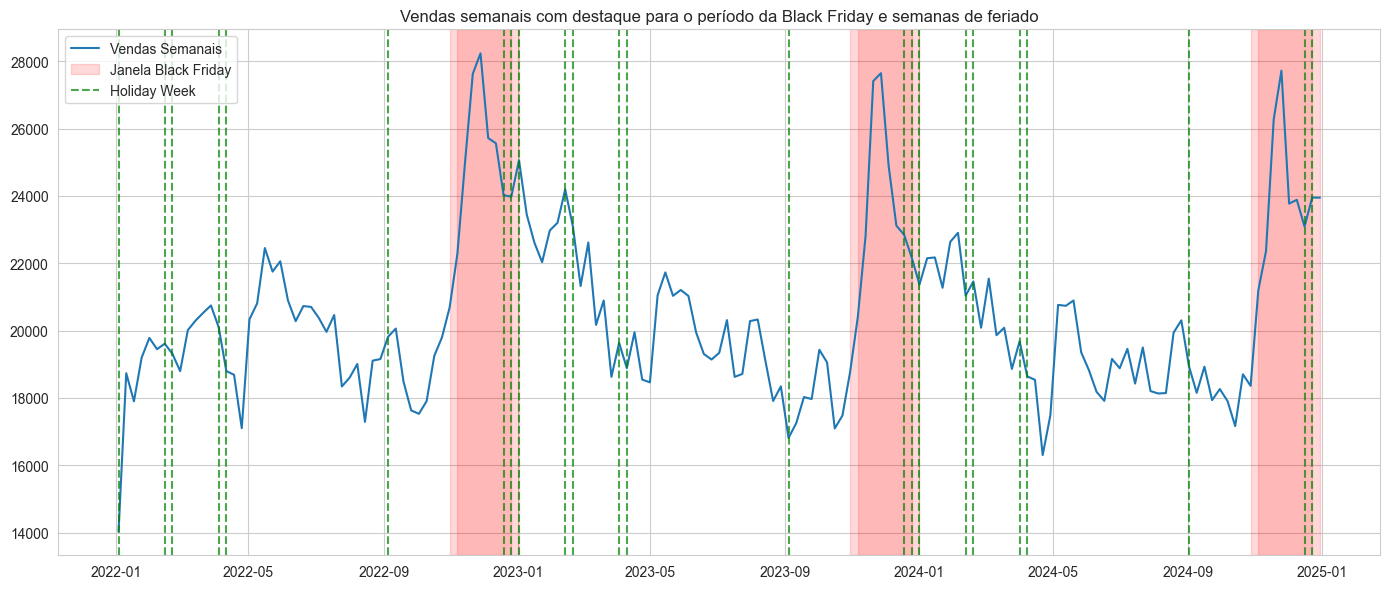

In [147]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df[TARGET_COLUMN], label="Vendas Semanais")

label_bf = False
for bf in bf_dates:
    ax.axvspan(
        bf - Week(3),
        bf + Week(5),
        color="red",
        alpha=0.15,
        label="Janela Black Friday" if not label_bf else None
    )
    label_bf = True

for i, d in enumerate(datas_holiday_week):
    ax.axvline(
        d,
        color="green",
        linestyle="--",
        alpha=0.7,
        label="Holiday Week" if i == 0 else None
    )

ax.set_title("Vendas semanais com destaque para o período da Black Friday e semanas de feriado")
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()


#### 5.2.1 - Black Friday

In [148]:
# Cálculo do lift da Black Friday comparando o valor do target na semana do evento com a média das semanas vizinhas (antes e depois)
lift_bf_nb = df.loc[df['bf_window'] == 1, TARGET_COLUMN].mean()/df.loc[df['bf_neighbor'] == 1, TARGET_COLUMN].mean()

lift_bf = df.loc[df['bf_window'] == 1, TARGET_COLUMN].mean()/df.loc[df['bf_window'] == 0, TARGET_COLUMN].mean()

print(f"Lift da Black Friday: {lift_bf_nb:.2f}x (ou {lift_bf_nb - 1:.2%} de aumento em relação às semanas vizinhas)")
print(f"Lift da Black Friday: {lift_bf:.2f}x (ou {lift_bf - 1:.2%} de aumento em relação ao resto do ano)")

Lift da Black Friday: 1.16x (ou 16.10% de aumento em relação às semanas vizinhas)
Lift da Black Friday: 1.21x (ou 21.20% de aumento em relação ao resto do ano)


#### 5.2.2 - Holiday Weeks

In [149]:
lift_holiday = df.loc[df['holiday_week'] == 1, TARGET_COLUMN].mean()/df.loc[df['holiday_week'] == 0, TARGET_COLUMN].mean()

print(f"Lift de semanas com feriados: {lift_holiday:.2f}x (ou {lift_holiday - 1:.2%} de aumento em relação às semanas sem feriados)")

Lift de semanas com feriados: 1.02x (ou 2.42% de aumento em relação às semanas sem feriados)


C:\Users\vinni\AppData\Local\Temp\ipykernel_14520\3397390438.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(["Non-Holiday", "Holiday"])


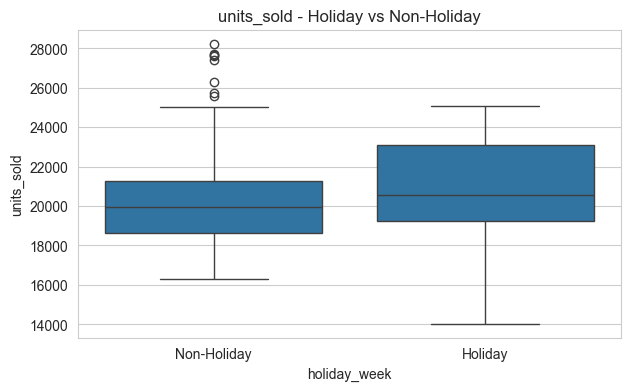

In [150]:
fig, axes = plt.subplots(figsize=(7,4))

sns.boxplot(
    x="holiday_week",
    y=TARGET_COLUMN,
    data=df,
    ax=axes
)
axes.set_title(f"{TARGET_COLUMN} - Holiday vs Non-Holiday")
axes.set_xticklabels(["Non-Holiday", "Holiday"])

plt.show()

In [151]:
df["zscore"] = (df[TARGET_COLUMN] - df[TARGET_COLUMN].mean()) / df[TARGET_COLUMN].std()

outliers = df[np.abs(df["zscore"]) > 3][
    [TARGET_COLUMN, "is_black_friday", "holiday_week", "zscore"]
]

outliers

,units_sold,is_black_friday,holiday_week,zscore
date,,,,
2022-11-28,28233,1,0,3.134876


A análise da série temporal de vendas indica a presença de semanas atípicas concentradas em períodos específicos, notadamente durante a Black Friday. A comparação entre o volume de vendas nas semanas classificadas como Black Friday e a média das semanas vizinhas mostra um lift médio de aproximadamente 16%, chegando a mais de 21% quando comparado ao restante do ano. Além disso, essas semanas podem apresentar z-scores superiores a 3, caracterizando desvios estatisticamente relevantes.

Esse comportamento consistente e recorrente confirma a Black Friday como um evento exógeno estrutural, que não deve ser tratado como ruído ou removido, mas sim explicitamente modelado por meio de uma variável dummy. A sua inclusão é fundamental para evitar que o modelo atribua esse aumento excepcional de vendas aos canais de mídia, o que resultaria em vieses nos coeficientes e na estimativa de ROI.

Em relação às semanas com feriados, observa-se um efeito positivo leve, com vendas em média cerca de 2% superiores às semanas sem feriados, além de maior dispersão na distribuição. Apesar de o impacto ser moderado, ele sugere a presença de variações exógenas na demanda que não estão diretamente relacionadas às ações de marketing. Dessa forma, a variável `holiday_week` é mantida como controle no modelo para capturar essas flutuações e contribuir para uma melhor estimativa do baseline de vendas.

Por fim, não foram identificados outliers extremos sem explicação causal clara. Os principais desvios observados estão associados a eventos conhecidos, reforçando a decisão de não remover observações, mas sim tratá-las adequadamente no modelo.

### 5.3 - Análise da Série Temporal AS-IS

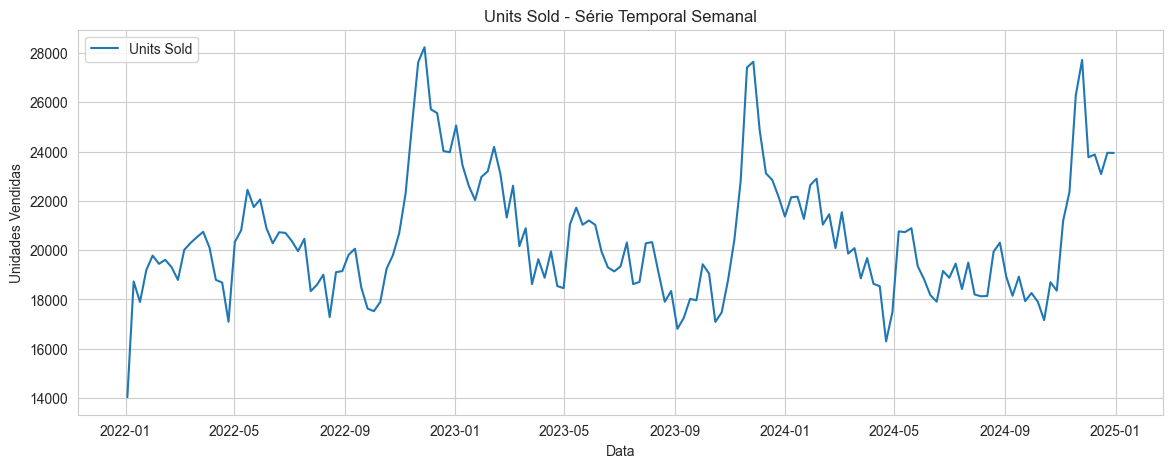

In [152]:
plt.figure(figsize=(14, 5))
plt.plot(y, label="Units Sold")
plt.title("Units Sold - Série Temporal Semanal")
plt.ylabel("Unidades Vendidas")
plt.xlabel("Data")
plt.legend()
plt.show()

#### 5.3.1 - Decomposição de Série Temporal do Target

- Verificação do crescimento orgânico da varejo360 (Tendência)
- Observação do impacto causado pela sazonalidade
- Identificação de resíduos que podem ser picos causados pelas campanhas de Marketing ou Outliers

**Escolha do STL (Seasonal and Trend decomposition using Loess)** <br>
STL é preferível ao seasonal_decompose porque é mais robusto a outliers típicos de picos de mídia, estima melhor tendências <br>
não lineares e permite modelar sazonalidade anual em séries semanais de forma mais estável, evitando viés nos coeficientes do modelo.

Hiperparâmetros utilizados:
- period = 52 → sazonalidade anual (365 dias ~ 52 semanas)
- robust = True → Captura picos de mídia, promoções atípicas e eventos únicos como resíduos (não influenciam tendência e sazonalidade)

In [153]:
stl = STL(
    y,
    period=52,
    robust=True
)

result = stl.fit()

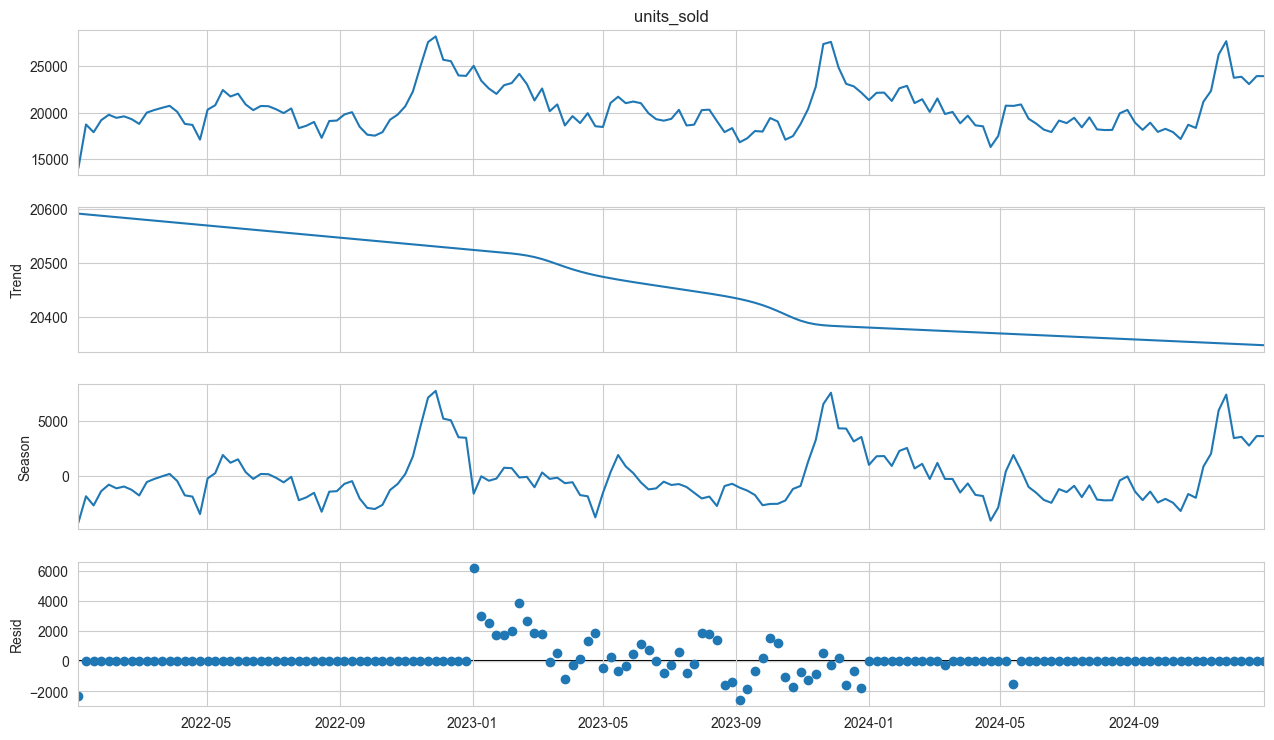

In [154]:
fig = result.plot()
fig.set_size_inches(14, 8)
plt.show()

In [155]:
# Criando dataframe com os componentes da decomposição para análises posteriores
df_decomp = pd.DataFrame({
    "units_sold": y,
    "trend": result.trend,
    "seasonality": result.seasonal,
    "residual": result.resid
})

#### 5.3.2 - Análise da **Tendência**

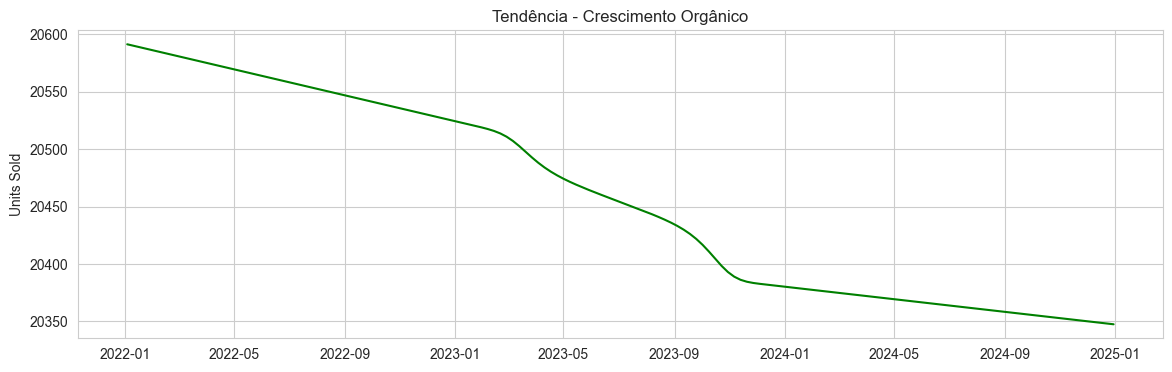

In [156]:
plt.figure(figsize=(14, 4))
plt.plot(df_decomp["trend"], color="green")
plt.title("Tendência - Crescimento Orgânico")
plt.ylabel("Units Sold")
plt.show()

Verifica-se uma queda ao longo do período analisado, contudo, isso representa uma queda de apenas 1.23% durante os 3 anos observados.

#### 5.3.3 - Análise de **Sazonalidade**

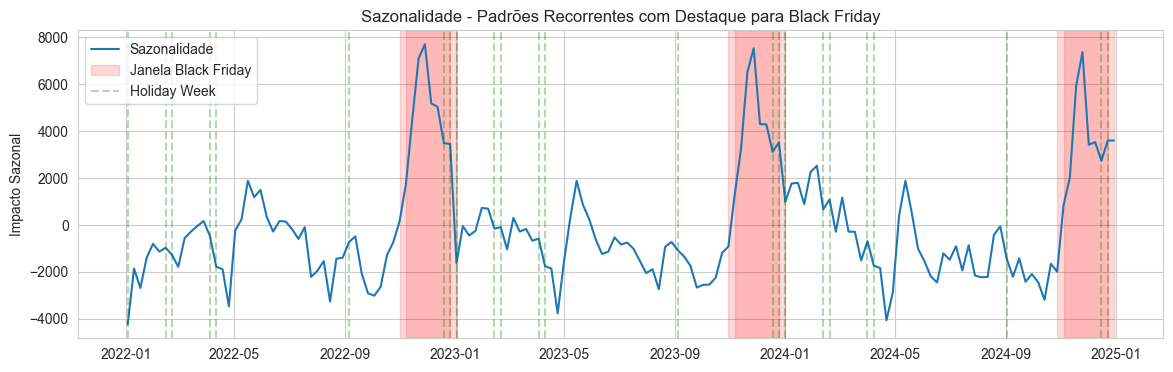

In [157]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_decomp.index, df_decomp["seasonality"], label="Sazonalidade")

label_bf = False
for bf in bf_dates:
    ax.axvspan(
        bf - Week(3),
        bf + Week(5),
        color="red",
        alpha=0.15,
        label="Janela Black Friday" if not label_bf else None
    )
    label_bf = True
    
for i, d in enumerate(datas_holiday_week):
    ax.axvline(
        d,
        color="green",
        linestyle="--",
        alpha=0.3,
        label="Holiday Week" if i == 0 else None
    )

ax.set_title("Sazonalidade - Padrões Recorrentes com Destaque para Black Friday")
ax.set_ylabel("Impacto Sazonal")
ax.legend(loc='upper left')

plt.show()


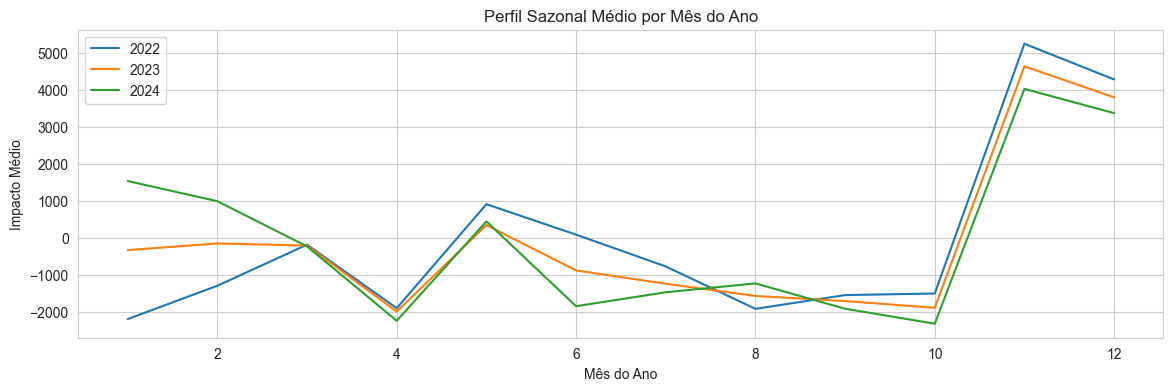

In [158]:
season_month = df_decomp.groupby(
    [df_decomp.index.month, df_decomp.index.year]
).agg({'seasonality': 'mean'})['seasonality'].unstack(level=1)

plt.figure(figsize=(14, 4))
plt.plot(season_month, label=season_month.columns.values)
plt.title("Perfil Sazonal Médio por Mês do Ano")
plt.xlabel("Mês do Ano")
plt.ylabel("Impacto Médio")
plt.legend()
plt.show()

#### 5.3.4 - Análise dos **Resíduos**

In [159]:
threshold = df_decomp["residual"].std() * 3

outliers = df_decomp[
    np.abs(df_decomp["residual"]) > threshold
]

outliers[["units_sold", "residual"]]

,units_sold,residual
date,,
2023-01-02,25059,6158.790544
2023-01-09,23449,2970.917305
2023-02-13,24191,3831.163665


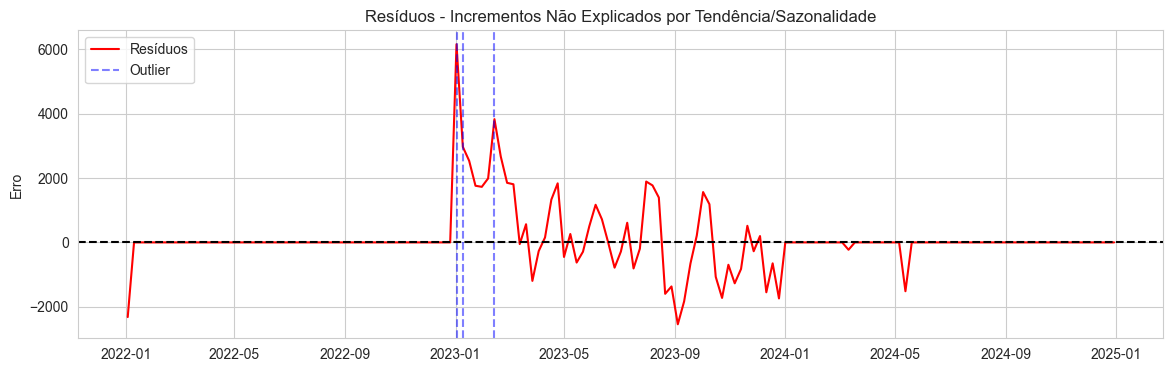

In [160]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_decomp["residual"], label="Resíduos", color="red")

for i, d in enumerate(outliers.index.values):
    ax.axvline(
        d,
        color="blue",
        linestyle="--",
        alpha=0.5,
        label="Outlier" if i == 0 else None
    )
    
ax.axhline(0, linestyle="--", color="black")
ax.set_title("Resíduos - Incrementos Não Explicados por Tendência/Sazonalidade")
ax.set_ylabel("Erro")
ax.legend(loc='upper left')
plt.show()


In [161]:
adf_result = adfuller(df_decomp["residual"].dropna())

print(f"ADF Statistic: {adf_result[0]:.3f}")
print(f"p-value: {adf_result[1]:.5f}")

ADF Statistic: -2.813
p-value: 0.05638


O teste ADF aplicado aos resíduos da decomposição STL resultou em um p-value marginalmente acima de 5%, sugerindo uma leve evidência de não estacionariedade. <br>
Dado o tamanho reduzido da amostra e a presença de eventos promocionais recorrentes, esse resultado é interpretado como aceitável no contexto de MMM. <br>
Entretanto, a seguir, será realizado o pré-tratamento do evento da Black Friday para tornar os resíduos da distribuição mais estacionários. 

### 5.4 - Análise da Série Temporal com pré-tratamento de Black Friday

Embora a Black Friday apresente caráter recorrente, sua intensidade e sincronização com investimentos de mídia variam ao longo do tempo. Por isso, optou-se por tratá-la como um evento exógeno via variável dummy, evitando que seu impacto fosse absorvido indevidamente pela sazonalidade.

In [162]:
df_adj = df.copy()

In [163]:
bf_dates = pd.to_datetime(datas_black_friday)

In [164]:
# Nestes pesos foi levado em conta que, no dataset disponibilizado, existem marcações sempre em duas semanas consecutivas antes da Black Friday.
weights = {
    -3: 0.2,
    -2: 0.3,
    -1: 0.5,
     0: 0.7,
     1: 0.5,
     2: 0.4,
     3: 0.3,
     4: 0.2,
     5: 0.15
}

df_adj["bf_weighted"] = 0.0

for bf in bf_dates:
    for lag, w in weights.items():
        date = bf + Week(lag)
        if pd.to_datetime(date) in df_adj.index:
            df_adj.loc[date, "bf_weighted"] += w

In [165]:
# Calculando o parâmetro bf_effect como o impacto médio por unidade de peso da janela de Black Friday
bf_effect = (
    (df_adj["bf_weighted"] * df_adj["units_sold"]).sum()
    / df_adj["bf_weighted"].sum()
    - df_adj.loc[df_adj["bf_weighted"] == 0, "units_sold"].mean()
)

print(f"Impacto Médio Estimado da Black Friday (bf_effect): {bf_effect:.2f} unidades vendidas por unidade de peso")

df_adj["units_sold_adj"] = df_adj["units_sold"] - df_adj["bf_weighted"] * bf_effect

Impacto Médio Estimado da Black Friday (bf_effect): 5247.33 unidades vendidas por unidade de peso


In [166]:
stl_adj = STL(
    df_adj["units_sold_adj"],
    period=52,
    robust=True
)

result_adj = stl_adj.fit()

In [167]:
# Criando dataframe com os componentes da decomposição para análises posteriores
df_decomp_adj = pd.DataFrame({
    "units_sold": y,
    "trend": result_adj.trend,
    "seasonality": result_adj.seasonal,
    "residual": result_adj.resid
})

#### 5.4.1 - Análise de **Sazonalidade** - Comparação entre a decomposição com e sem tratamento da Black Friday

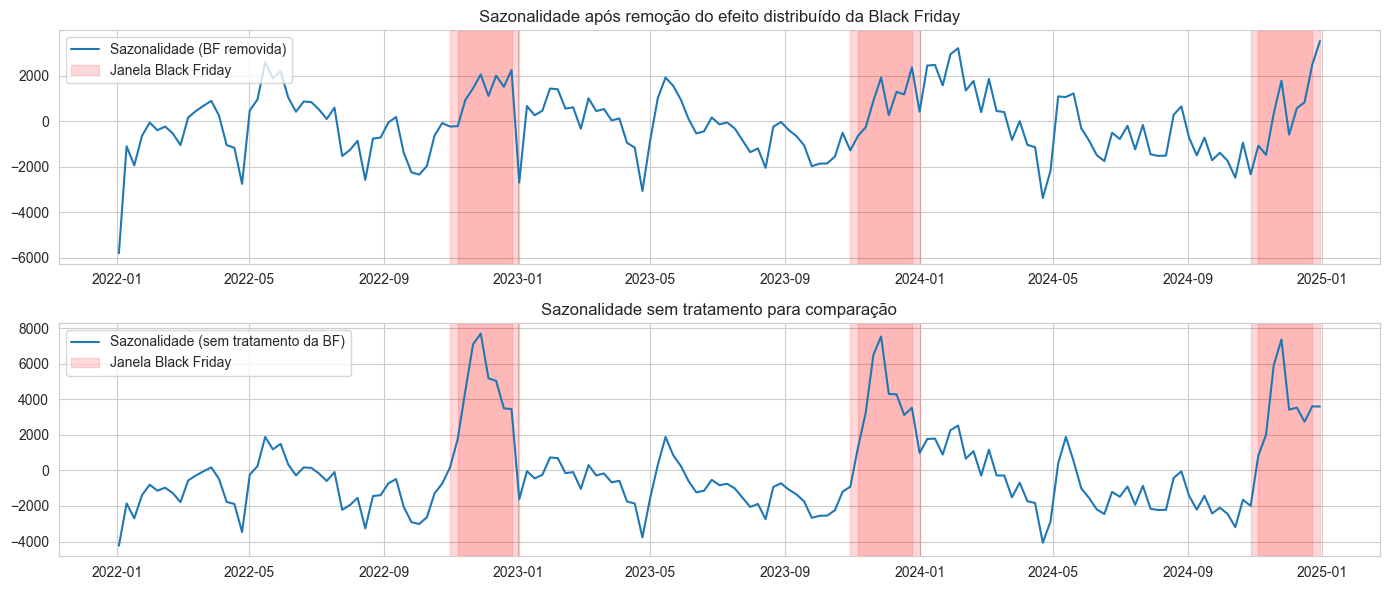

In [168]:
fig, ax = plt.subplots(2, 1, figsize=(14, 6))

ax[0].plot(df_adj.index, result_adj.seasonal, label="Sazonalidade (BF removida)")

label_bf = False
for bf in bf_dates:
    ax[0].axvspan(
        bf - Week(3),
        bf + Week(5),
        color="red",
        alpha=0.15,
        label="Janela Black Friday" if not label_bf else None
    )
    label_bf = True

ax[0].set_title("Sazonalidade após remoção do efeito distribuído da Black Friday")
ax[0].legend(loc='upper left')


ax[1].plot(df.index, result.seasonal, label="Sazonalidade (sem tratamento da BF)")
label_bf = False
for bf in bf_dates:
    ax[1].axvspan(
        bf - Week(3),
        bf + Week(5),
        color="red",
        alpha=0.15,
        label="Janela Black Friday" if not label_bf else None
    )
    label_bf = True

ax[1].set_title("Sazonalidade sem tratamento para comparação")
ax[1].legend()

plt.tight_layout()
plt.show()


Como o STL não aceita variáveis exógenas, o tratamento da Black Friday foi feito via pré-ajuste da série: estimou-se separadamente o efeito distribuído do evento e o choque identificado foi removido antes da decomposição. Assim, a sazonalidade estimada representa apenas padrões estruturais, enquanto o impacto promocional é tratado explicitamente como controle no MMM.

Apesar de modelarmos a Black Friday com uma dinâmica semelhante a um adstock, ela permanece uma variável de controle, pois não representa uma decisão de alocação de mídia. O adstock aqui é usado apenas para capturar a persistência temporal de um choque exógeno, evitando que seu efeito seja indevidamente atribuído aos canais.

#### 5.4.2 Análise de **Tendência**

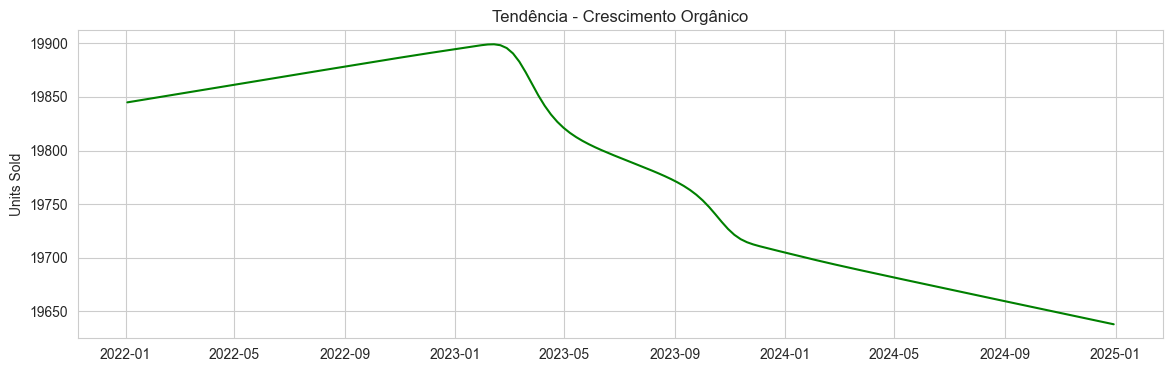

In [169]:
plt.figure(figsize=(14, 4))
plt.plot(df_decomp_adj["trend"], color="green")
plt.title("Tendência - Crescimento Orgânico")
plt.ylabel("Units Sold")
plt.show()

#### 5.4.3 - Análise de **Resíduos**

In [170]:
threshold = df_decomp_adj["residual"].std() * 3

outliers = df_decomp_adj[
    np.abs(df_decomp_adj["residual"]) > threshold
]

outliers[["units_sold", "residual"]]

,units_sold,residual
date,,
2023-01-02,25059,7079.112784
2023-02-13,24191,3745.775304


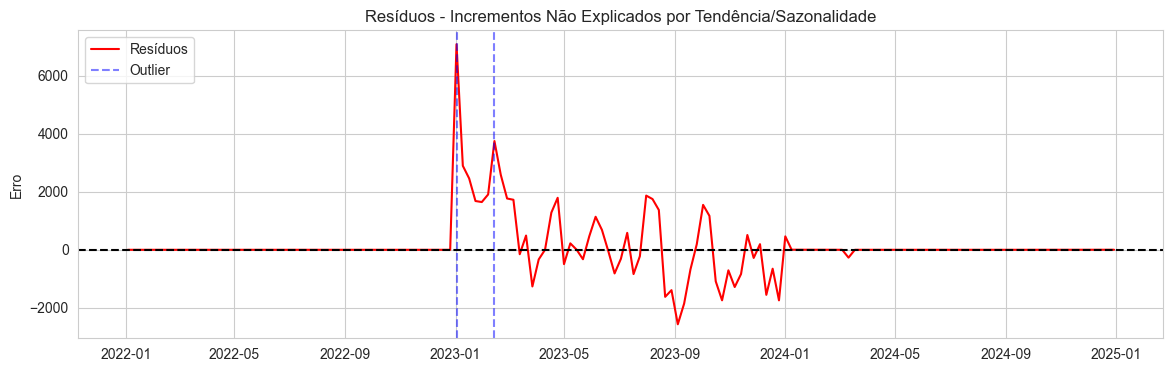

In [171]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_decomp_adj["residual"], label="Resíduos", color="red")

for i, d in enumerate(outliers.index.values):
    ax.axvline(
        d,
        color="blue",
        linestyle="--",
        alpha=0.5,
        label="Outlier" if i == 0 else None
    )

ax.axhline(0, linestyle="--", color="black")
ax.set_title("Resíduos - Incrementos Não Explicados por Tendência/Sazonalidade")
ax.set_ylabel("Erro")
ax.legend(loc='upper left')
plt.show()


In [172]:
adf_result = adfuller(df_decomp_adj["residual"].dropna())

print(f"ADF Statistic: {adf_result[0]:.3f}")
print(f"p-value: {adf_result[1]:.5f}")

ADF Statistic: -6.697
p-value: 0.00000


Inicialmente, os resíduos da decomposição apresentavam evidência marginal de não estacionariedade, sugerindo que eventos promocionais relevantes ainda estavam contaminando o baseline. <br>
Após modelar explicitamente a Black Friday como um choque exógeno com efeito distribuído no tempo e remover esse impacto antes da decomposição, <br> os resíduos tornaram-se claramente estacionários (ADF p-value < 0.001), indicando que a estrutura temporal foi adequadamente isolada.

### 5.5 - Análise de Investimento em mídia



#### 5.5.1 - Análise de Padrões de Investimento

Nesta etapa será verificado o comportamento da empresa quanto aos canais de mídia. Se são realizadas campanhas Always-On ou Flighting.

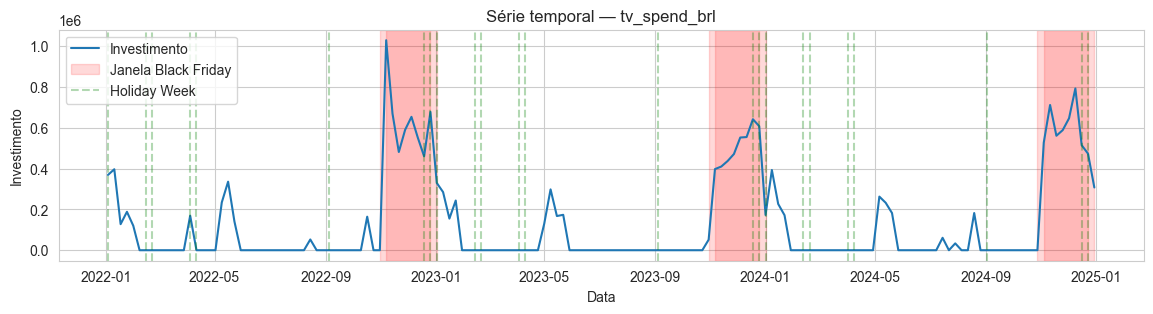

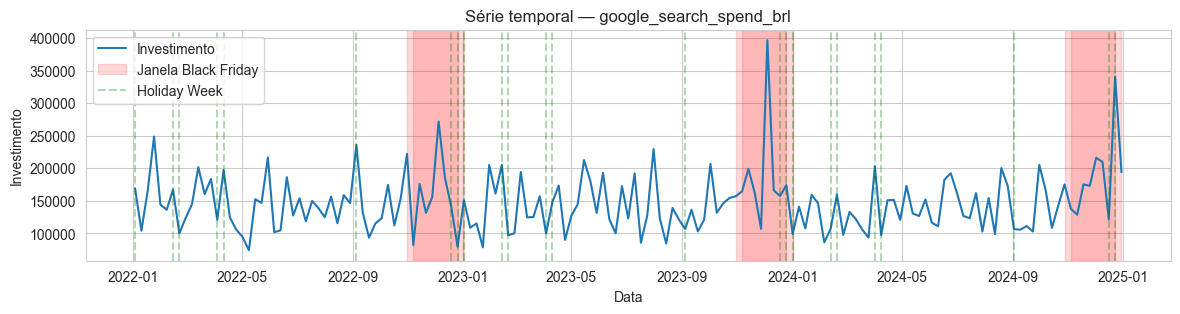

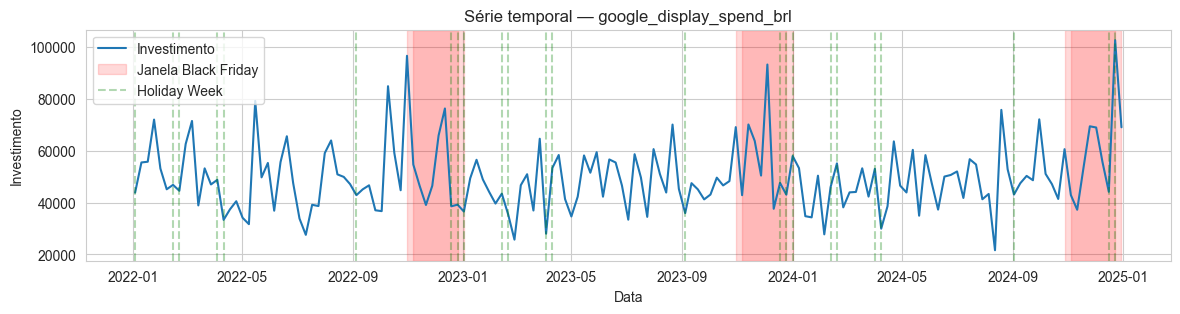

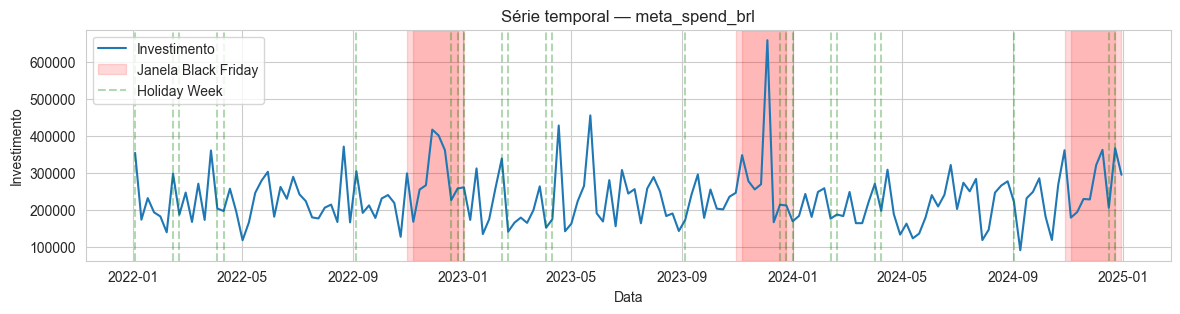

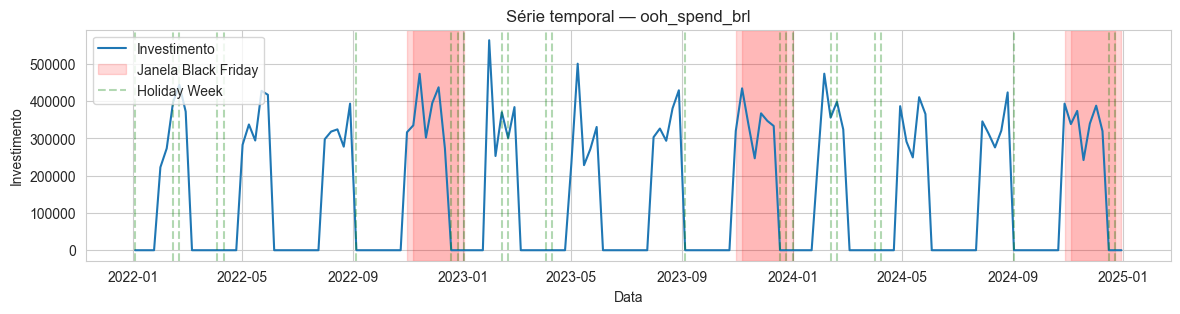

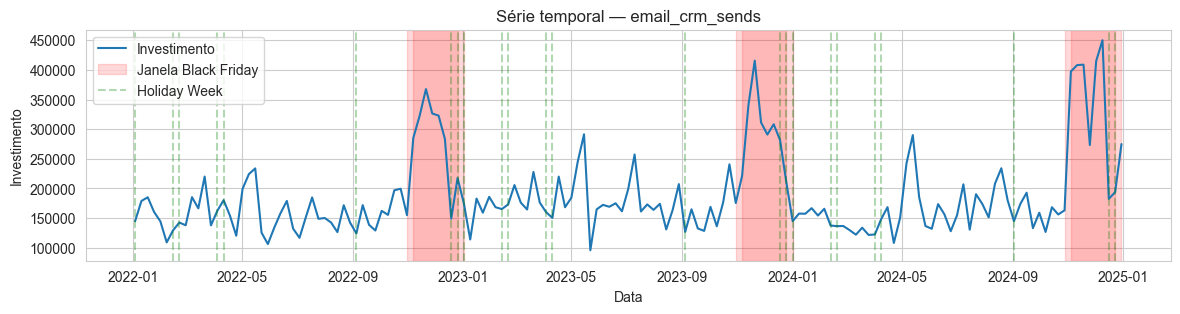

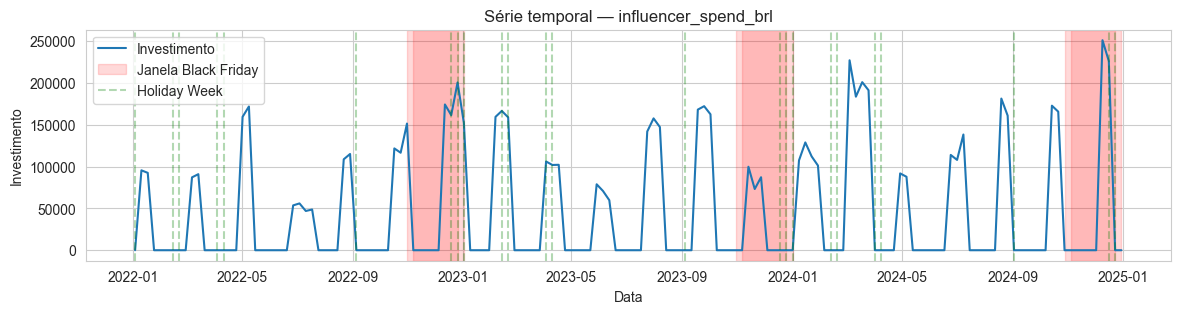

In [173]:
for channel in media_channels:
    fig, ax = plt.subplots(figsize=(14, 3))

    ax.plot(df.index, df[channel], label='Investimento')

    label_bf = False
    for bf in bf_dates:
        ax.axvspan(
            bf - Week(3),
            bf + Week(5),
            color="red",
            alpha=0.15,
            label="Janela Black Friday" if not label_bf else None
        )
        label_bf = True

    for i, d in enumerate(datas_holiday_week):
        ax.axvline(
            d,
            color="green",
            linestyle="--",
            alpha=0.3,
            label="Holiday Week" if i == 0 else None
        )
    ax.set_title(f"Série temporal — {channel}")
    ax.set_xlabel("Data")
    ax.set_ylabel("Investimento")
    ax.legend(loc='upper left')
    plt.show()


O padrão de flighting observado nos dados sugere ativações coordenadas entre canais, trazendo simultaneidade de investimento e elevada multicolinearidade. Isso reduz a capacidade do MMM de identificar efeitos incrementais isolados, exigindo cautela na interpretação dos coeficientes e reforçando a importância de controles sazonais e escolhas cuidadodas de variáveis.

#### 5.5.2 - Métricas Quantitativas de Investimento

In [174]:
flighting_summary = []

for channel in media_channels:
    series = df[channel]

    summary = {
        "canal": channel,
        "% semanas ativas": pct_active(series),
        "media gasto (quando ativo)": series[series > 0].mean(),
        "coef_variacao (quando ativo)": coeff_variation(series),
        "num_bursts": count_bursts(series)
    }

    flighting_summary.append(summary)

flighting_df = pd.DataFrame(flighting_summary)
flighting_df.sort_values("% semanas ativas", ascending=False)

,canal,% semanas ativas,media gasto (quando ativo),coef_variacao (quando ativo),num_bursts
1,google_search_spend_brl,1.000000,146985.375478,0.314813,1
2,google_display_spend_brl,1.000000,49590.792675,0.266372,1
3,meta_spend_brl,1.000000,231282.099172,0.326819,1
5,email_crm_sends,1.000000,186898.617834,0.369836,1
4,ooh_spend_brl,0.420382,344216.348939,0.204915,12
6,influencer_spend_brl,0.356688,131670.169286,0.366817,20
0,tv_spend_brl,0.350318,369985.075636,0.600260,13


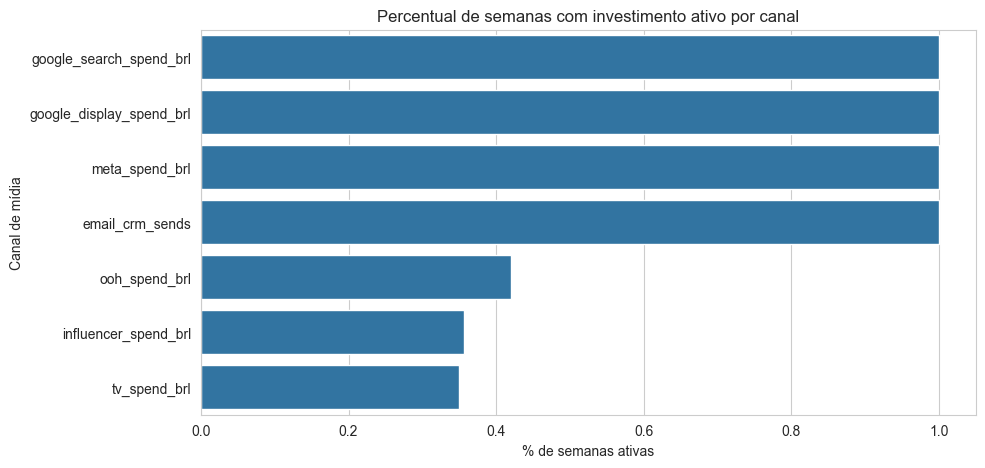

In [175]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=flighting_df.sort_values("% semanas ativas", ascending=False),
    x="% semanas ativas",
    y="canal"
)
plt.title("Percentual de semanas com investimento ativo por canal")
plt.xlabel("% de semanas ativas")
plt.ylabel("Canal de mídia")
plt.show()

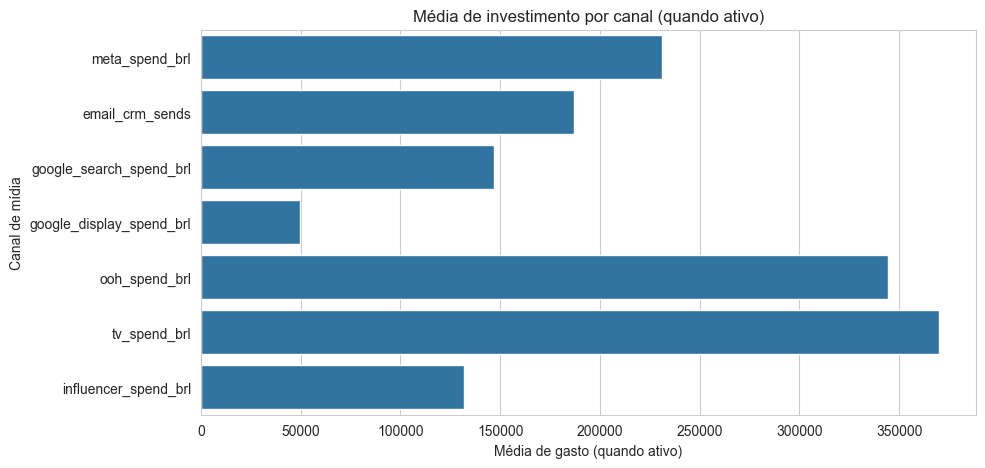

In [176]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=flighting_df.sort_values(["num_bursts", "media gasto (quando ativo)"], ascending=[True, False]),
    x="media gasto (quando ativo)",
    y="canal"
)
plt.title("Média de investimento por canal (quando ativo)")
plt.xlabel("Média de gasto (quando ativo)")
plt.ylabel("Canal de mídia")
plt.show()

##### Flighting - Liga/Desliga vs Always-on

Observando-se os investimentos, é possível verificar os seguintes formatos:<br>
**Flighting**
- `tv_spend_brl`
- `ooh_spend_brl`
- `influencer_spend_brl` <br>

**Always-On**
- `google_search_spend_brl`
- `google_display_spend_brl`
- `meta_spend_brl` <br>

**Híbrido (Always-On + Flighting)**
- `email_crm_sends`


TV, OOH e Influencers apresentam padrão claro de flighting, com longos períodos sem investimento seguidos de bursts concentrados. <br> 
Já Google e Meta operam de forma predominantemente contínua, sugerindo comportamento always-on. <br>
Por fim, emails possuem comportamento híbrido sendo sempre presentes, mas com intensidade maior durante o período da Black Friday. <br> 

Essas diferenças têm implicações diretas na modelagem:
- Canais em flighting exigem maior atenção à calibração de adstock, dado o efeito de memória.
- Canais always-on tendem a apresentar maior correlação entre si, aumentando o risco de multicolinearidade.


### 5.6 - Estudo de Multicolinearidade

Correlação alta entre canais compromete a identificação causal, pois o modelo não consegue separar efeitos marginais individuais de cada mídia.

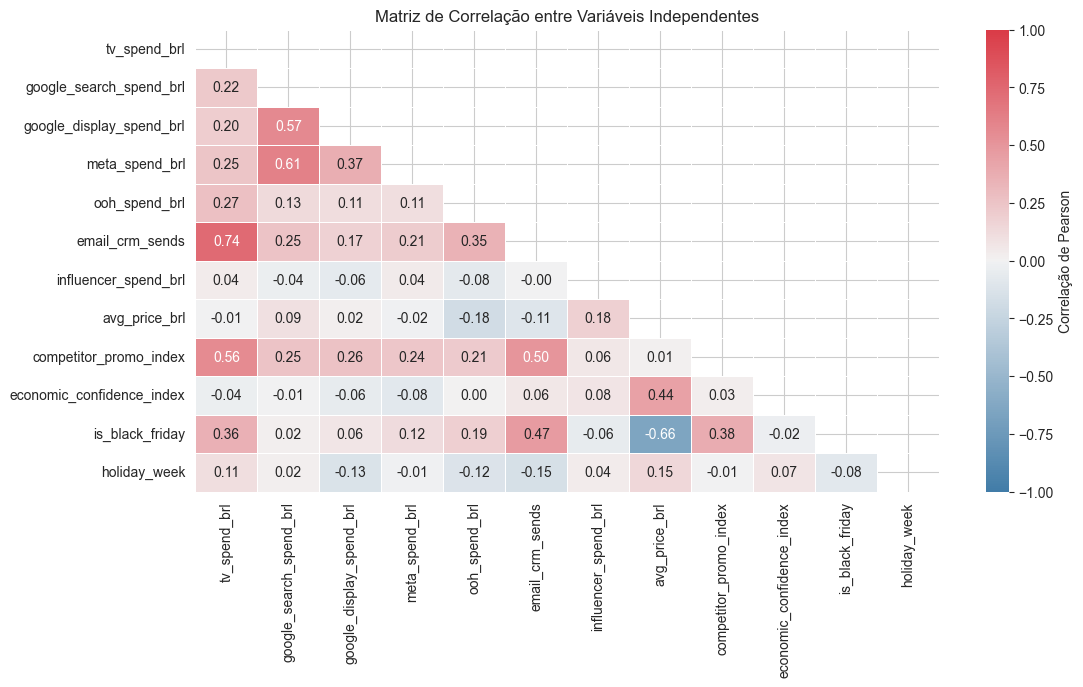

In [177]:
media_and_controls = media_channels + control_features
plt.figure(figsize=(12, 6))

corr = df[media_and_controls].corr(method="pearson")

cmap = sns.diverging_palette(240, 10, as_cmap=True)  # azul->vermelho
# Máscara para mostrar apenas triângulo inferior
mask = np.triu(np.ones_like(corr, dtype=bool))


ax = sns.heatmap(
        corr,
        mask=mask,
        cmap=cmap,
        vmin=-1,
        vmax=1,  # intensidade fixa em [-1, 1]
        center=0,
        annot=True,
        fmt=".2f",  # anotações opcionais
        linewidths=0.5,
        cbar_kws={"label": "Correlação de Pearson"},
    )

ax.set_title('Matriz de Correlação entre Variáveis Independentes')
plt.show()


#### 5.6.1 - Insights retirados da análise de correlação
A matriz de correlação entre as variáveis independentes indica que não há multicolinearidade extrema generalizada, mas existem blocos específicos de variáveis com correlação moderada a alta, que impõem limitações claras à identificação causal dos efeitos individuais no modelo de MMM.

##### Correlação elevada entre TV e Email CRM
> tv_spend_brl ↔ email_crm_sends: 0.74
- Indica que a orquestração de campanhas que envolvem bursts de mídia de TV são acompanhados de ativações de CRM.
- **Decisão**: Manter ambos, com ressalvas de limitação de identificação.

##### Correlação moderada entre canais digitais de performance
> Google Search ↔ Meta Ads: 0.61 <br>
> Google Search ↔ Google Display: 0.57 <br>
> Meta Ads ↔ Google Display: 0.37 <br>
- Indica planejamentos digitais conjuntos, com alocação simultânea entre canais do mesmo stack de performance.
- Esses canais competem pela mesma demanda latente.
- Modelo conseguirá capturar bem o efeito combinado dos canais, porém não será necessariamente preciso na distinção entre os canais.
- **Decisão**: Manter canais separados e considerar as limitações.

##### Relação entre TV e pressão competitiva
> tv_spend_brl ↔ competitor_promo_index: 0.56 <br>
- Indica aumento de investimento em TV em períodos de maior agressividade promocional da concorrência.
- Não implica causalidade, mas correlação por reação estratégica.
- **Decisão**: Utilizar a pressão competitiva como variável controle.

##### Black Friday e variáveis operacionais
> is_black_friday ↔ avg_price_brl: -0.66 <br>
> is_black_friday ↔ economic_confidence_index: 0.38 <br>
> is_black_friday ↔ email_crm_sends: 0.47 <br>
- Queda estrutural do preço na Black Friday valida as correlações com preço e sentimento dos consumidores.
- Durante a Black Friday é possível observar forte atuação do CRM.
- **Decisão**: Utilizar a flag `is_black_friday` como variável controle.

##### Variáveis com baixa colinearidade
- `influencer_spend_brl` apresenta correlação próxima de zero com quase todos os canais.
- `holiday_week` tem correlações baixas e difusas.


A análise de multicolinearidade indica que, embora não haja colinearidade extrema generalizada, existem blocos de variáveis — especialmente TV, CRM e canais digitais — que variam de forma coordenada ao longo do tempo. <br>
Isso impõe limites claros à identificação causal individual dos coeficientes de mídia. Como consequência, decisões de inclusão de variáveis de controle, aceitação de trade-offs entre ajuste e inferência, e foco na interpretação conjunta de canais são fundamentais para garantir estabilidade e coerência do modelo.




### 5.7 - Identificação de Desafios Causais


#### 5.7.1 - Vendas vs Comissões e Cupons
Verificação de Endogeneidade

Hipótese causal:

Unidades Vendidas → Cupons Resgatados<br>
Unidades Vendidas → Comissão de Afiliados

Logo, `affiliate_commission_brl` e `coupons_redeemed` não são causas independentes de vendas, são funções determinísticas ou quase determinísticas das vendas.

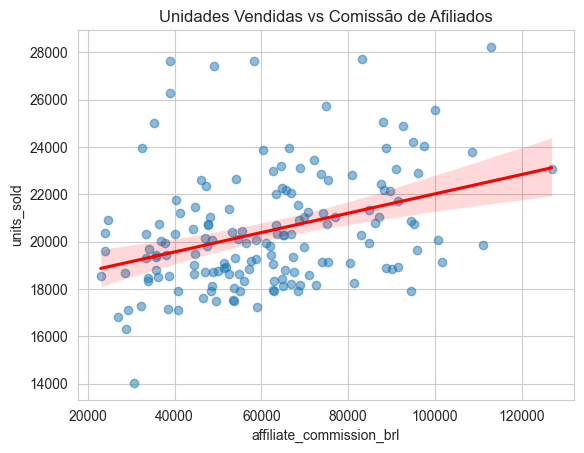

In [178]:
sns.regplot(
    data=df,
    x="affiliate_commission_brl",
    y="units_sold",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)
plt.title("Unidades Vendidas vs Comissão de Afiliados")
plt.show()



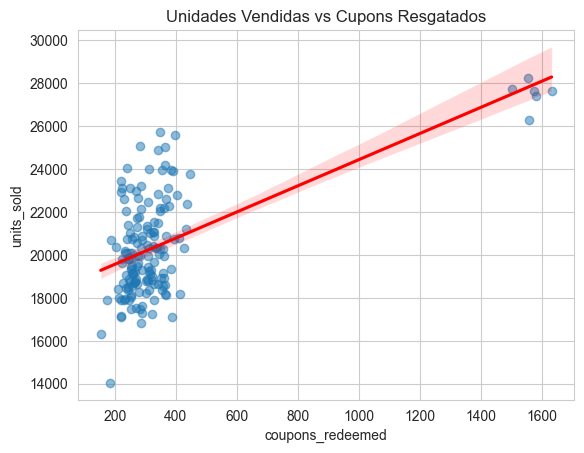

In [179]:
sns.regplot(
    data=df,
    x="coupons_redeemed",
    y="units_sold",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)
plt.title("Unidades Vendidas vs Cupons Resgatados")
plt.show()

Tratando Outliers de `coupons_redeemed`

In [180]:
df.loc[df['coupons_redeemed'] > df['coupons_redeemed'].mean() + 3 * df['coupons_redeemed'].std(), 'coupons_redeemed'] = np.round(df['coupons_redeemed'].mean())

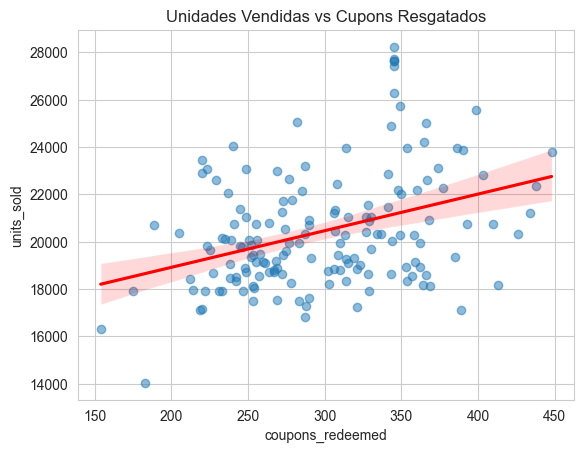

In [181]:
sns.regplot(
    data=df,
    x="coupons_redeemed",
    y="units_sold",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)
plt.title("Unidades Vendidas vs Cupons Resgatados")
plt.show()

Apesar de a relação visual entre `units_sold` e `affiliate_commission_brl`/`coupons_redeemed` não ser perfeitamente linear, a questão central não é correlação, mas endogeneidade estrutural. <br>
Ambas as variáveis são consequências diretas do evento de venda, ocorrendo no mesmo momento ou após a transação, e portanto não podem ser tratadas como causas independentes de demanda. <br>
A dispersão observada decorre de variações no ticket médio, mix de produtos e uso de descontos, mas não altera a direção causal fundamental. <br>
A inclusão dessas variáveis introduziria viés por simultaneidade e comprometeria a interpretação causal dos coeficientes do modelo de MMM.

**Conclusão**: Excluir `affiliate_commission_brl` e `coupons_redeemed` da modelagem.

##### Analisando pela ótica de `revenue_brl`

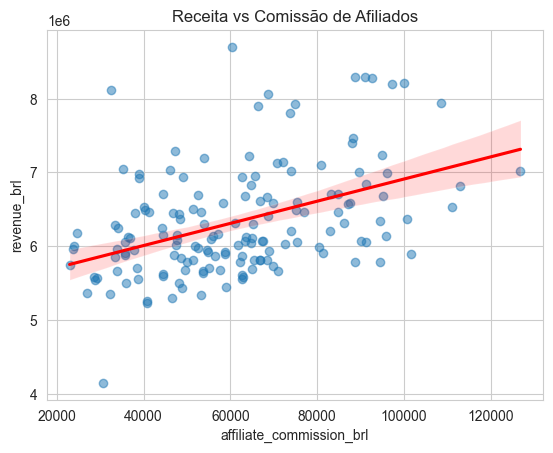

In [182]:
sns.regplot(
    data=df,
    x="affiliate_commission_brl",
    y="revenue_brl",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)
plt.title("Receita vs Comissão de Afiliados")
plt.show()



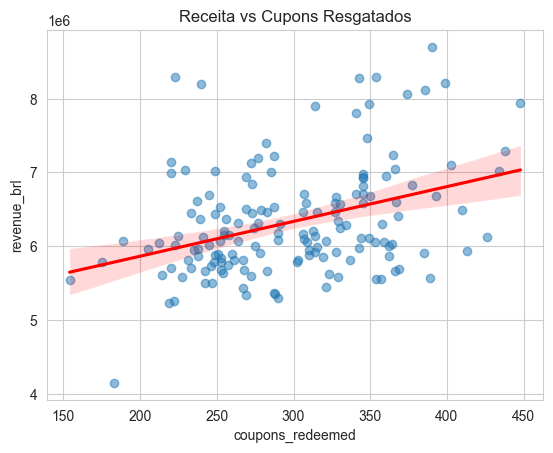

In [183]:
sns.regplot(
    data=df,
    x="coupons_redeemed",
    y="revenue_brl",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)
plt.title("Receita vs Cupons Resgatados")
plt.show()

Ao utilizar `revenue_brl` como variável target, observa-se uma relação quase linear entre receita e `affiliate_commission_brl`, bem como uma forte associação positiva com `coupons_redeemed`.
Essa relação não representa causalidade no sentido requerido pelo MMM, mas sim endogeneidade estrutural: ambas as variáveis são consequências diretas da própria venda, calculadas no momento da transação com base no valor faturado. <br>
A inclusão dessas variáveis no modelo introduziria viés por simultaneidade, inflando o poder explicativo e competindo indevidamente com os canais de mídia pela variância da receita.
Portanto, `affiliate_commission_brl` e `coupons_redeemed` são excluídas do modelo por não serem causas independentes de demanda, apesar de sua alta associação com o target.

#### 5.7.2 - Mídia vs Sessões no Site e Leads Gerados
Verificação de Competição pela Causa <br>

Hipótese Causal: <br>
Mídia → Sessões/Leads → Vendas

In [184]:
df["total_media_spend"] = df[media_channels].sum(axis=1)

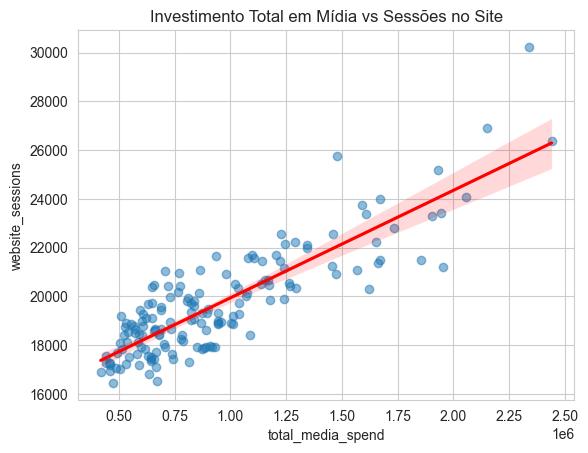

In [185]:
sns.regplot(
    data=df,
    x="total_media_spend",
    y="website_sessions",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)
plt.title("Investimento Total em Mídia vs Sessões no Site")
plt.show()

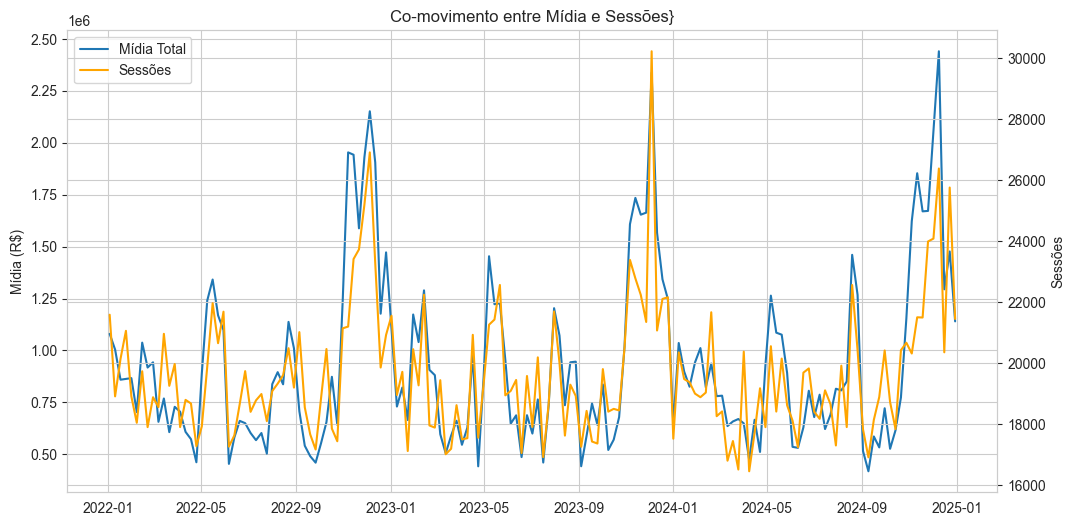

In [186]:
fig, ax1 = plt.subplots(figsize=(12,6))

l1, = ax1.plot(df.index, df["total_media_spend"], label="Mídia Total")
ax1.set_ylabel("Mídia (R$)")

ax2 = ax1.twinx()
l2, = ax2.plot(df.index, df["website_sessions"], color="orange", label="Sessões")
ax2.set_ylabel("Sessões")


# Junta as legendas dos dois eixos
lines = [l1, l2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Co-movimento entre Mídia e Sessões}")
plt.show()

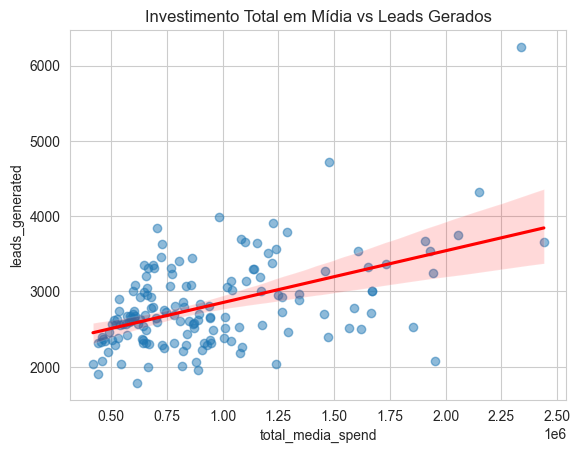

In [187]:
sns.regplot(
    data=df,
    x="total_media_spend",
    y="leads_generated",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)
plt.title("Investimento Total em Mídia vs Leads Gerados")
plt.show()

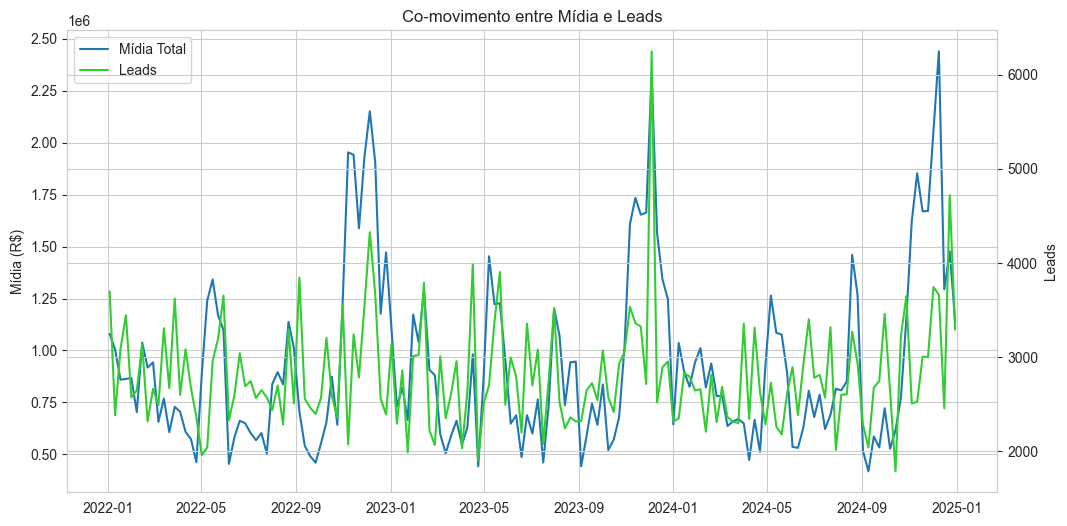

In [188]:
fig, ax1 = plt.subplots(figsize=(12,6))

l1, = ax1.plot(df.index, df["total_media_spend"], label="Mídia Total")
ax1.set_ylabel("Mídia (R$)")

ax2 = ax1.twinx()
l2, = ax2.plot(df.index, df["leads_generated"], color="limegreen", label="Leads")
ax2.set_ylabel("Leads")


# Junta as legendas dos dois eixos
lines = [l1, l2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Co-movimento entre Mídia e Leads")
plt.show()

A análise visual mostra forte correlação e co-movimento entre investimento total em mídia e `website_sessions`. Além disso, existe certa correlação positiva entre `leads_generated` e o investimento em mídia.<br>
Isso caracteriza `website_sessions` e `leads_generated` como variáveis mediadoras do efeito da mídia, e não drivers independentes de vendas. <br>
A inclusão destas no modelo absorveria parte do efeito que deveria ser atribuído corretamente aos canais de mídia.

**Conclusão:** excluir `website_sessions` e `leads_generated` da modelagem.

### 5.8 - Análise de Elasticidade Preço-Demanda

In [189]:
df_decomp_adj["avg_price_brl"] = df["avg_price_brl"]

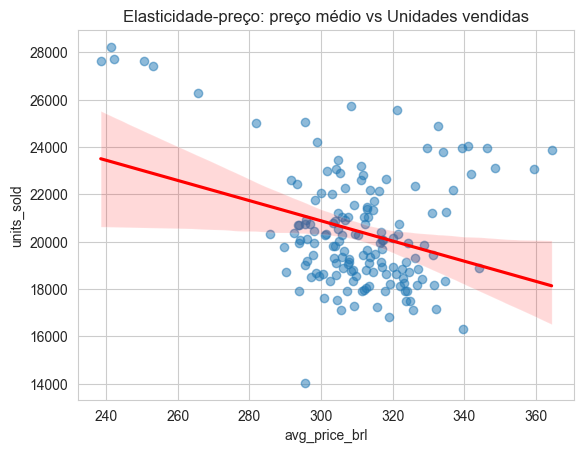

In [190]:
sns.regplot(
    data=df,
    x="avg_price_brl",
    y="units_sold",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)
plt.title("Elasticidade-preço: preço médio vs Unidades vendidas")
plt.show()

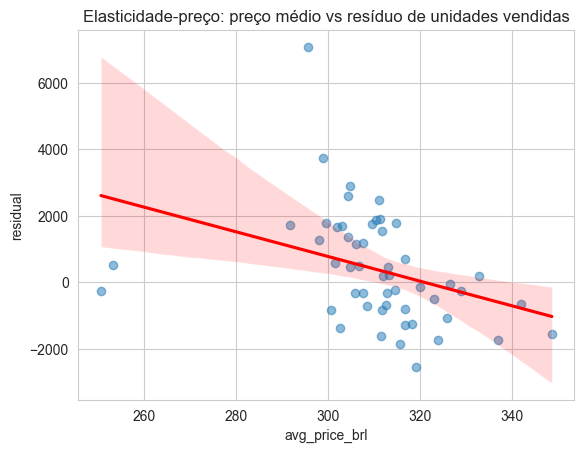

In [191]:
sns.regplot(
    data=df_decomp_adj[np.abs(df_decomp_adj['residual'])>10], # Filtrando apenas aqueles com resíduo significativo
    x="avg_price_brl",
    y="residual",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)
plt.title("Elasticidade-preço: preço médio vs resíduo de unidades vendidas")
plt.show()

Para isolar o efeito do preço da influência de eventos promocionais extremos, foi analisada a relação entre `avg_price_brl` e o resíduo de `units_sold` após remover o efeito da Black Friday. <br>
Observa-se uma relação negativa consistente: aumentos no preço médio estão associados a desempenho abaixo do esperado em unidades vendidas. <br>
Esse resultado reforça a presença de elasticidade-preço negativa estrutural e justifica a inclusão de `avg_price_brl` como uma variável de controle central no modelo de MMM. <br>
Controlar adequadamente o efeito do preço é essencial para evitar que variações comerciais sejam indevidamente atribuídas aos canais de mídia, distorcendo a estimativa de ROI.

## 6 - Realizando a Modelagem

In [192]:
# Utilizando o número de vendas ajustado para o efeito da Black Friday como target para modelagem
TARGET_COLUMN_MODEL = "units_sold_adj"

In [193]:
# Trazendo informações de tendência e sazonalidade extraídas na EDA para o dataset de modelagem
df_adj['trend'] = df_decomp_adj['trend']
df_adj['seasonality'] = df_decomp_adj['seasonality']

In [194]:
# Adicionando tendência e sazonalidade às variáveis controles
control_features = control_features + ['trend', 'seasonality']

### 6.1 - Definindo a separação do dataframe em treino/teste e validação (Out Of Time)
Data de corte escolhida `2024-07-01` → 27 semanas de validação (6 meses) ~ 17% do dataset

In [195]:
index_val = df_adj.index >= pd.to_datetime('2024-07-01')

### 6.2 - Modelo Baseline Utilizando statsmodels

#### 6.2.1 - Funções Suporte do modelo

In [196]:
def adstock_geometric(series, lam):
    """
    Aplica adstock geométrico: x_{t} + lambda * x_{t-1}
    """
    adstocked = np.zeros(len(series))
    for i in range(len(series)):
        if i == 0:
            adstocked[i] = series.iloc[i]
        else:
            adstocked[i] = series.iloc[i] + lam * adstocked[i-1]
    return pd.Series(adstocked, index=series.index)

In [197]:
def hill_saturation(x, K, n=1):
    """
    Função Hill para retornos decrescentes
    """
    return (x ** n) / (K ** n + x ** n)

In [198]:
def response_curve(df, df_mmm, model, channel, max_spend_mult=2, steps=50):
    spend = df[channel].mean()
    spend_range = np.linspace(0, spend * max_spend_mult, steps)

    ad = adstock_geometric(
        pd.Series(spend_range),
        adstock_params[channel]
    )

    K = df_mmm[f'{channel}_adstock'].median()
    sat = hill_saturation(ad, K=K)

    coef = model.params[f'{channel}_sat']
    response = coef * sat

    return spend_range, response

In [199]:
def plot_response_curve(spend, response, channel, ax):
    ax.plot(spend, response, label=channel)
    ax.set_title(f"Curva de Resposta - {channel}")
    if channel == 'email_crm_sends':
        ax.set_xlabel("e-mails enviados semanalmente")
    else:
        ax.set_xlabel("Investimento semanal (R$)")
    ax.set_ylabel("Unidades Vendidas Incrementais")
    return ax

#### 6.2.2 - Definição de parâmetros iniciais (priors) de Adstock
Os priors de adstock foram definidos com o objetivo de refletir hipóteses causais plausíveis sobre a dinâmica temporal de cada canal de mídia, incorporando conhecimento prévio obtido na análise exploratória dos dados (EDA) e em práticas consolidadas de Marketing Mix Modeling (MMM).

In [200]:
adstock_params = {
    'tv_spend_brl': 0.7,
    'google_search_spend_brl': 0.1,
    'google_display_spend_brl': 0.3,
    'meta_spend_brl': 0.3,
    'ooh_spend_brl': 0.6,
    'email_crm_sends': 0.4,
    'influencer_spend_brl': 0.5
}


#### 6.2.3 - Aplicação de Adstock + Saturação

In [201]:
df_mmm = df_adj.copy()

for channel in media_channels:
    # Adstock
    df_mmm[f'{channel}_adstock'] = adstock_geometric(
        df_mmm[channel],
        adstock_params[channel]
    )

    # Saturação (não aplicar em CRM se quiser ser conservador)
    if channel != 'email_crm_sends':
        K = df_mmm[f'{channel}_adstock'].median()
        df_mmm[f'{channel}_sat'] = hill_saturation(
            df_mmm[f'{channel}_adstock'], K=K, n=1
        )
    else:
        df_mmm[f'{channel}_sat'] = df_mmm[f'{channel}_adstock']

In [202]:
# Inclusão de Tendência e Sazonalidade (da STL)
df_mmm['trend'] = df_decomp_adj['trend']
df_mmm['seasonality'] = df_decomp_adj['seasonality']

In [203]:
# Dataset de modelagem
df_fit = df_mmm[~index_val]

# Dataset de validação
df_val = df_mmm[index_val]

In [204]:
media_features = [f'{c}_sat' for c in media_channels]

control_features = [
    'avg_price_brl',
    'competitor_promo_index',
    'economic_confidence_index',
    'is_black_friday',
    'holiday_week',
    'trend',
    'seasonality'
]

X = df_fit[media_features + control_features]
y = df_fit['units_sold']

In [205]:
X = add_constant(X)

#### 6.2.4 - Estimação do Modelo

In [206]:
baseline_model = OLS(y, X).fit()
print(baseline_model.summary())

                            OLS Regression Results                            
Dep. Variable:             units_sold   R-squared:                       0.920
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                     94.85
Date:                Wed, 13 May 2026   Prob (F-statistic):           2.99e-56
Time:                        00:13:48   Log-Likelihood:                -1031.9
No. Observations:                 130   AIC:                             2094.
Df Residuals:                     115   BIC:                             2137.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

#### 6.2.5 - Diagnóstico de Multicolinearidade

| Faixa de VIF | Interpretação | Implicação no Modelo |
|-------------|---------------|----------------------|
| **VIF = 1** | Não há multicolinearidade. O preditor não está correlacionado com outros preditores. | Não há aumento do erro padrão nem impacto negativo na estabilidade do coeficiente. |
| **VIF entre 1 e 5** | Multicolinearidade moderada. Existe alguma correlação com outros preditores, mas geralmente não é grave. | O modelo permanece estável, porém é recomendável monitorar esses preditores, especialmente se outros VIFs forem elevados. |
| **VIF > 5** | Alta multicolinearidade. | O erro padrão do coeficiente pode estar inflado, tornando a estimativa menos confiável. Pode ser necessário remover, transformar ou combinar preditores correlacionados. |
| **VIF > 10** | Multicolinearidade grave. | O coeficiente provavelmente está instável e pouco interpretável. Normalmente são necessárias ações corretivas, como remover o preditor ou aplicar técnicas de regularização. |

In [207]:
vif_df = pd.DataFrame({
    'feature': X.columns,
    'VIF': [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

vif_df.sort_values('VIF', ascending=False)

,feature,VIF
0,const,180223.581896
11,is_black_friday,3.990026
8,avg_price_brl,3.529254
6,email_crm_sends_sat,2.736908
13,trend,2.515105
10,economic_confidence_index,2.424460
14,seasonality,2.002501
9,competitor_promo_index,1.853504
1,tv_spend_brl_sat,1.802135
2,google_search_spend_brl_sat,1.625456


O diagnóstico de multicolinearidade indica VIFs abaixo de 5 para todas as variáveis explicativas, o que sugere níveis moderados e aceitáveis de correlação entre os regressores. <br> 
Valores mais elevados são observados para variáveis estruturais como preço, Black Friday e tendência, refletindo correlações esperadas e inerentes ao comportamento temporal e promocional do varejo. <br>

#### 6.2.6 - Contribuições Incrementais por Canal

In [208]:
contributions = pd.DataFrame(index=df_fit.index)

for channel in media_channels:
    col = f'{channel}_sat'
    coef = baseline_model.params[col]
    contributions[channel] = coef * df_fit[col]

In [209]:
total_contribution = contributions.sum().sort_values(ascending=False)
print(total_contribution)

meta_spend_brl              472520.198900
email_crm_sends             293207.861309
tv_spend_brl                116945.557422
influencer_spend_brl        113464.826627
ooh_spend_brl                49651.009987
google_search_spend_brl     -11047.646910
google_display_spend_brl   -115278.425391
dtype: float64


A contribuição negativa estimada para Google Display e Google Search não indica que os canais destroem vendas, mas sim que, condicionalmente às demais mídias e controles presentes no modelo, o investimento neles não apresentou efeito incremental positivo. <br> 
Esse resultado é consistente com o papel típico do canal como suporte e redistribuição de demanda, especialmente em ambientes onde Meta, Search e CRM já capturam grande parte da intenção. Esse tipo de estimativa reflete competição pela mesma variância explicativa.

- Estão redistribuindo conversões
- Não criam novas vendas
- Penalidade ao estimar o efeito marginal

In [210]:
# Baseline vs Incremental

df_fit['baseline'] = (
    baseline_model.params['const']
    + baseline_model.params['trend'] * df_fit['trend']
    + baseline_model.params['seasonality'] * df_fit['seasonality']
    + baseline_model.params['avg_price_brl'] * df_fit['avg_price_brl']
    + baseline_model.params['competitor_promo_index'] * df_fit['competitor_promo_index']
    + baseline_model.params['economic_confidence_index'] * df_fit['economic_confidence_index']
    + baseline_model.params['is_black_friday'] * df_fit['is_black_friday']
    + baseline_model.params['holiday_week'] * df_fit['holiday_week']
)

C:\Users\vinni\AppData\Local\Temp\ipykernel_14520\401920428.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fit['baseline'] = (


#### 6.2.7 - Curvas de Resposta por canal de Mídia

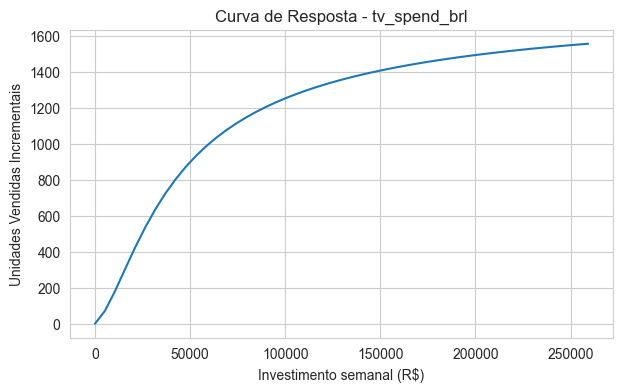

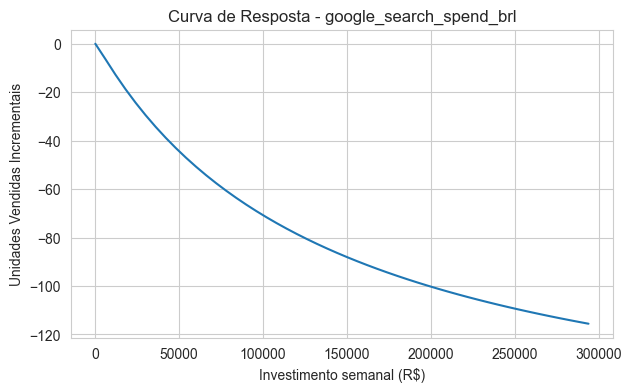

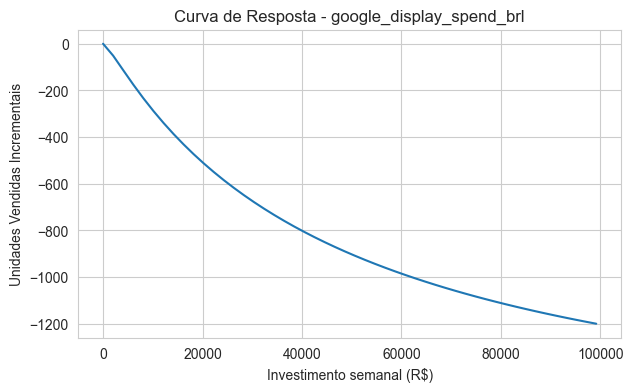

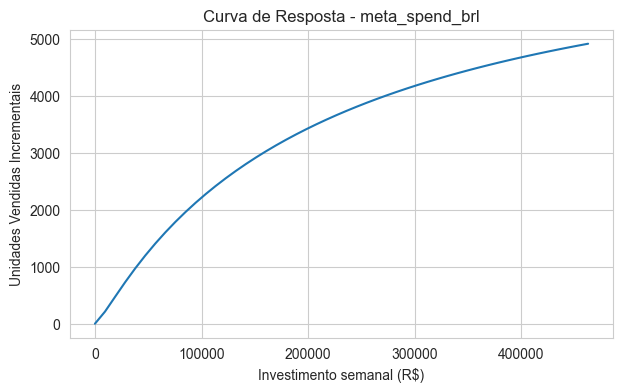

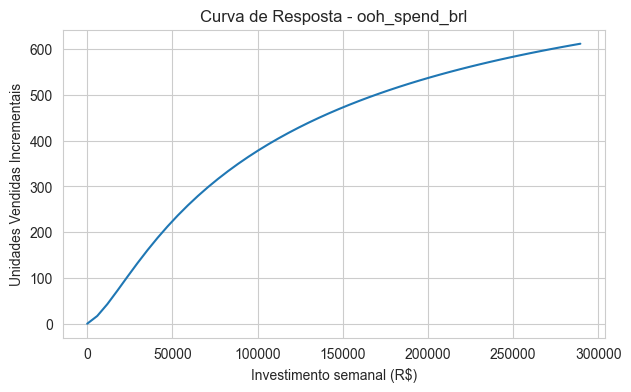

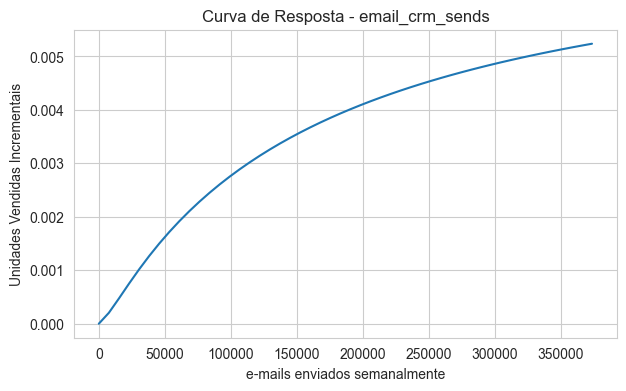

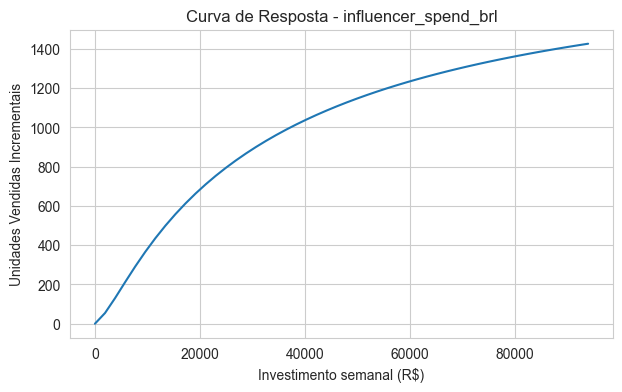

In [211]:
for channel in media_channels:
    fig, ax = plt.subplots(figsize=(7,4))
    spend, response = response_curve(df_adj, df_fit, baseline_model, channel)
    ax = plot_response_curve(spend, response, channel, ax)


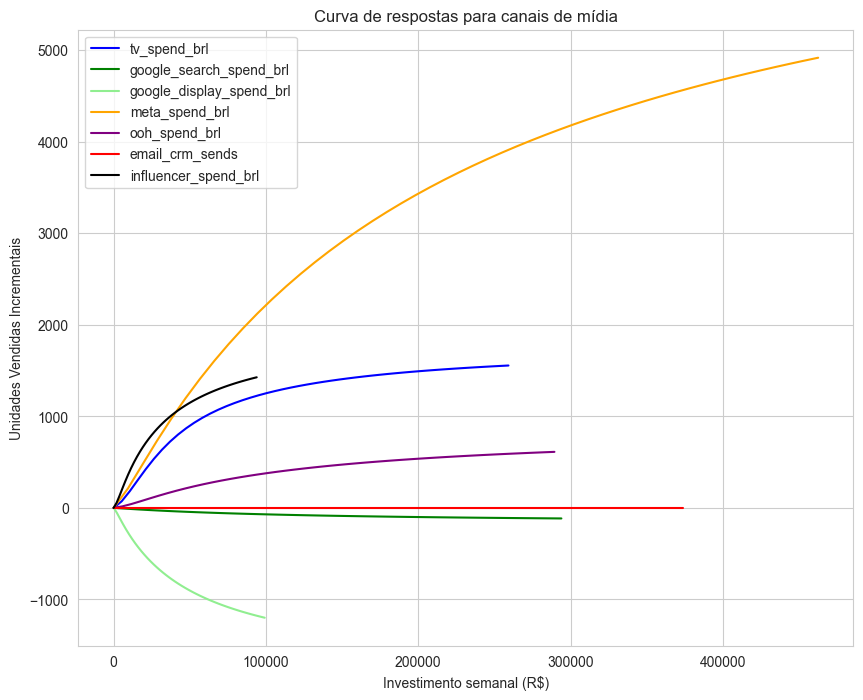

In [226]:
fig, ax = plt.subplots(figsize=(10,8))
colors = ['blue', 'green', 'lightgreen', 'orange', 'purple', 'red', 'black']  # List of colors for each channel
for i, channel in enumerate(media_channels):
    spend, response = response_curve(df_adj, df_fit, baseline_model, channel)
    ax.plot(spend, response, label=channel, color=colors[i])
ax.set_title("Curva de respostas para canais de mídia")
ax.legend(loc="upper left")
ax.set_xlabel("Investimento semanal (R$)")
ax.set_ylabel("Unidades Vendidas Incrementais")
plt.show()

No contexto observado, com os demais canais ativos, investir mais em Display não melhora resultados e pode piorar a eficiência do mix.

OBS: `email_crm_sends` está com a unidade de e-mails enviados e não com gastos em reais.

#### 6.2.8 - ROI por Canal

In [81]:
# Para corrigir o ROI do canal de CRM, assume-se um custo médio por envio (CPM) e calcula-se o gasto total com base no número de envios.
email_cpm = 10/1000  # Supondo 10R$ por 1.000 emails

avg_price = df_fit['avg_price_brl'].mean()

roi = {}

for channel in media_channels:
    units_inc = contributions[channel].sum()
    revenue_inc = units_inc * avg_price
    spend = df_fit[channel].sum()

    if channel == 'email_crm_sends':
        spend = spend * email_cpm

    roi[channel] = revenue_inc / spend

roi_df = pd.DataFrame.from_dict(roi, orient='index', columns=['ROI'])
roi_df.sort_values('ROI', ascending=False)

,ROI
email_crm_sends,387.233686
influencer_spend_brl,5.847871
meta_spend_brl,4.868709
tv_spend_brl,2.405747
ooh_spend_brl,0.819008
google_search_spend_brl,-0.180266
google_display_spend_brl,-5.592483


Os ROIs estimados apresentam sinais e ordens de grandeza coerentes com a função econômica dos canais. <br>
O canal de Email/CRM apresenta ROI muito elevado devido ao seu baixo custo marginal, refletindo alta eficiência, porém limitada escalabilidade. <br>
Canais de mídia paga como Meta, Influencer e TV apresentam ROIs moderados e positivos, consistentes com sua capacidade de gerar demanda incremental. <br> 
O Google Display e Google Search apresentam ROI negativo, indicando ausência de incrementalidade marginal e possível redistribuição de conversões, resultado coerente com suas contribuições negativas no modelo.


#### 6.2.9 - Validando o modelo nos dados de treino/teste com cross-validation em multiplos folds

In [82]:
def fit_mmm_model(X_train, y_train):
    """
    Treina o MMM com statsmodels OLS
    """
    X_train_const = add_constant(X_train)
    model = OLS(y_train, X_train_const).fit()
    return model

def predict_mmm_model(model, X):
    """
    Gera previsões a partir do modelo treinado
    """
    X_const = add_constant(X)
    return model.predict(X_const)

In [83]:
fold_dates = [
    "2023-05-01",
    "2023-09-01",
    "2024-01-01"
]

In [85]:
cv_results = []

for i, split_date in enumerate(fold_dates, 1):

    train_idx = df_fit.index < split_date
    val_idx   = df_fit.index >= split_date

    X_train, y_train = X.loc[train_idx], y.loc[train_idx]
    X_val, y_val     = X.loc[val_idx], y.loc[val_idx]

    model = fit_mmm_model(X_train, y_train)

    # Previsões
    y_pred_train = predict_mmm_model(model, X_train)
    y_pred_val   = predict_mmm_model(model, X_val)

    # Métrica diagnóstica (WAPE)
    wape_train = np.abs(y_train - y_pred_train).sum() / y_train.sum()
    wape_val   = np.abs(y_val - y_pred_val).sum() / y_val.sum()

    # Guardar resultados principais
    cv_results.append({
        "fold": i,
        "split_date": split_date,
        "wape_train": wape_train,
        "wape_val": wape_val,
        "coefficients": model.params
    })

In [86]:
cv_summary = pd.DataFrame([{
    "fold": r["fold"],
    "split_date": r["split_date"],
    "wape_train": r["wape_train"],
    "wape_val": r["wape_val"]
} for r in cv_results])

cv_summary

,fold,split_date,wape_train,wape_val
0,1,2023-05-01,0.019237,0.242103
1,2,2023-09-01,0.024910,0.071568
2,3,2024-01-01,0.025782,0.039236


A avaliação por cross‑validation temporal mostra redução progressiva do erro fora da amostra à medida que mais histórico é incorporado ao treinamento. <br>O primeiro fold apresenta erro mais elevado, consistente com menor disponibilidade de ciclos sazonais completos. <br>
Nos folds subsequentes, com o histórico maior, o WAPE de validação começa a diminuir para níveis mais baixos, indicando ausência de overfitting estrutural e coerência do modelo ao longo do tempo.

In [87]:
coef_df = pd.DataFrame({
    f"fold_{r['fold']}": r["coefficients"]
    for r in cv_results
})

coef_df

,fold_1,fold_2,fold_3
const,-751484.272492,-239219.181958,-131244.626769
tv_spend_brl_sat,1632.146404,1389.018772,1532.262933
google_search_spend_brl_sat,-616.171392,-1080.113552,368.694071
google_display_spend_brl_sat,-467.332422,-1645.056808,-2736.661947
meta_spend_brl_sat,7312.103208,8090.730981,7597.402206
ooh_spend_brl_sat,762.703101,1194.666047,975.765122
email_crm_sends_sat,0.008518,0.009650,0.009344
influencer_spend_brl_sat,1178.192757,1750.185104,2015.624456
avg_price_brl,-48.206500,-34.733602,-27.545994
competitor_promo_index,758.106392,906.655033,1341.762310


In [88]:
coef_variation = coef_df.pct_change(axis=1).abs().mean(axis=1)
coef_variation.sort_values(ascending=False)

is_black_friday                 7.617327
google_display_spend_brl_sat    1.591833
google_search_spend_brl_sat     1.047145
const                           0.566517
trend                           0.542535
ooh_spend_brl_sat               0.374795
competitor_promo_index          0.337925
influencer_spend_brl_sat        0.318573
holiday_week                    0.261686
avg_price_brl                   0.243209
economic_confidence_index       0.234071
tv_spend_brl_sat                0.126044
meta_spend_brl_sat              0.083730
email_crm_sends_sat             0.082248
seasonality                     0.029371
dtype: float64

- `google_search_spend_brl` atua majoritariamente como canal de captura de demanda já existente, com baixa incrementalidade marginal isolada.
- `google_display_spend_brl` não apresenta incrementalidade positiva condicional, possivelmente redistribuindo conversões capturadas por Meta, Search e CRM. Condicionalmente aos outros canais, aumentar Google Display não gera vendas incrementais e está estatisticamente associado a períodos de menor performance.

Os coeficientes estimados apresentam sinais e magnitudes consistentes ao longo dos folds de validação temporal, indicando estabilidade estrutural do modelo. <br> 
Os principais canais de mídia mantêm efeito incremental positivo, enquanto canais de suporte apresentam impacto marginal reduzido ou negativo, refletindo competição por demanda existente. <br>

## 7 - Validando o modelo no dataset de validação (simulação de produção)

### 7.1 - Análise da performance - estabilidade em relação ao dataset de treino

In [89]:
X_val = df_val[media_features + control_features]
y_val = df_val['units_sold']

X_val = add_constant(X_val)

y_pred_val = predict_mmm_model(baseline_model, X_val)

wape_val = np.abs(y_val - y_pred_val).sum() / y_val.sum()

In [90]:
print(f"WAPE no dataset de validação: {wape_val:.5f}")

WAPE no dataset de validação: 0.03267


WAPE continua estável comparando com o último fold do dataset de treino. <br> Isso indica a ausência de overfitting estrutural e a manutenção da coerência temporal. 

In [91]:
media_coef = {}
for channel in media_channels:
    media_coef[channel] = baseline_model.params[f"{channel}_sat"]

In [92]:
df_media_coef = pd.DataFrame({'media_channels':media_coef.keys(), 'media_coefs':media_coef.values()})

df_media_coef

,media_channels,media_coefs
0,tv_spend_brl,1794.959210
1,google_search_spend_brl,-170.951082
2,google_display_spend_brl,-1788.549225
3,meta_spend_brl,7262.017940
4,ooh_spend_brl,871.733586
5,email_crm_sends,0.007584
6,influencer_spend_brl,1942.479155


Os coeficientes estimados para os canais de mídia mantêm sinais e magnitudes coerentes com a interpretação causal esperada. Canais como Meta, TV e Influencer apresentam efeitos incrementais positivos e relevantes, enquanto Google Display permanece com contribuição negativa marginal, indicando possível sobreposição com outros canais digitais.

De forma geral, os resultados reforçam a estabilidade do modelo e sua capacidade de capturar relações econômicas plausíveis entre investimento em mídia e vendas, sem evidência de distorções significativas nesta etapa de validação.

### 7.1 - Contribuições Incrementais por Canal

In [93]:
contributions_val = pd.DataFrame(index=df_val.index)

for channel in media_channels:
    col = f'{channel}_sat'
    coef = baseline_model.params[col]
    contributions_val[channel] = coef * df_val[col]

In [94]:
total_contribution_val = contributions_val.sum().sort_values(ascending=False)
print(total_contribution_val)

meta_spend_brl              100324.810700
email_crm_sends              75513.837337
influencer_spend_brl         24875.572605
tv_spend_brl                 24373.632158
ooh_spend_brl                10602.206905
google_search_spend_brl      -2375.799093
google_display_spend_brl    -24959.386868
dtype: float64


In [95]:
# Baseline vs Incremental

df_val['baseline'] = (
    baseline_model.params['const']
    + baseline_model.params['trend'] * df_val['trend']
    + baseline_model.params['seasonality'] * df_val['seasonality']
    + baseline_model.params['avg_price_brl'] * df_val['avg_price_brl']
    + baseline_model.params['competitor_promo_index'] * df_val['competitor_promo_index']
    + baseline_model.params['economic_confidence_index'] * df_val['economic_confidence_index']
    + baseline_model.params['is_black_friday'] * df_val['is_black_friday']
    + baseline_model.params['holiday_week'] * df_val['holiday_week']
)

C:\Users\vinni\AppData\Local\Temp\ipykernel_14520\2299703891.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val['baseline'] = (


### 7.2 - Curvas de Resposta por Canal de Mídia 

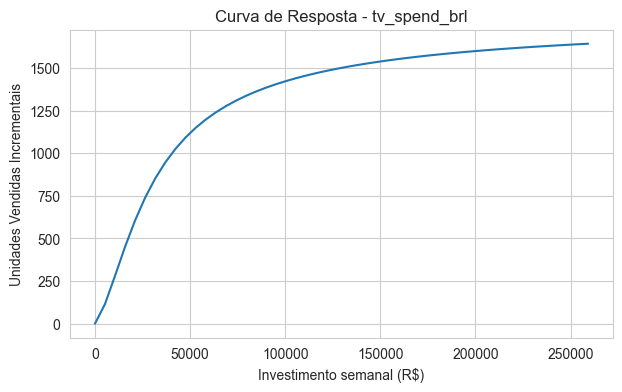

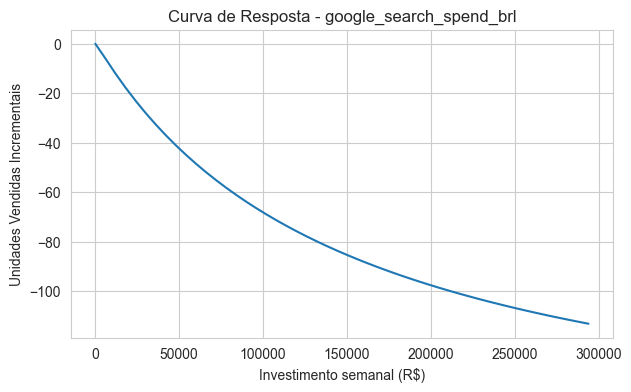

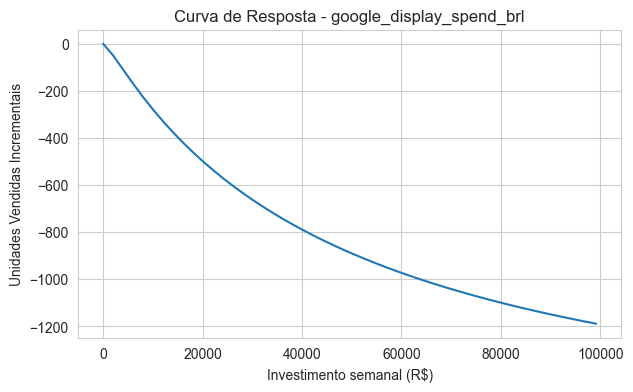

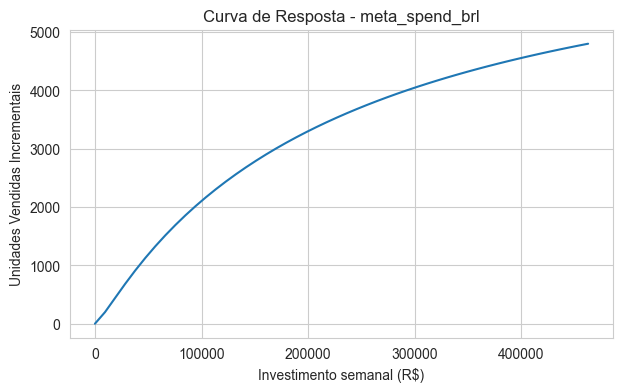

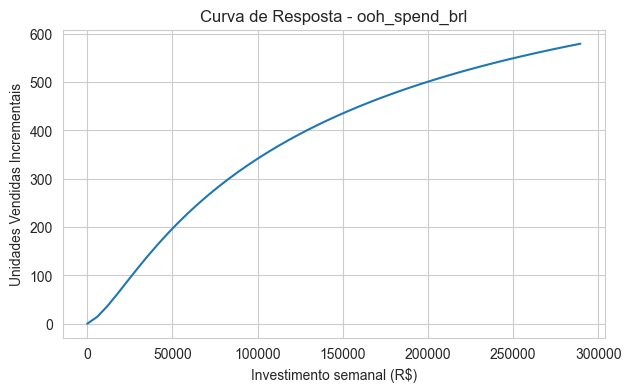

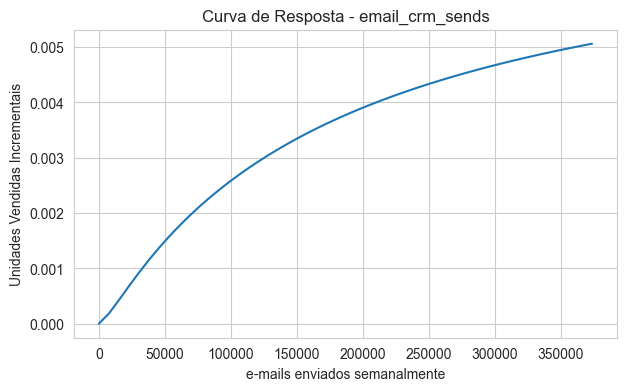

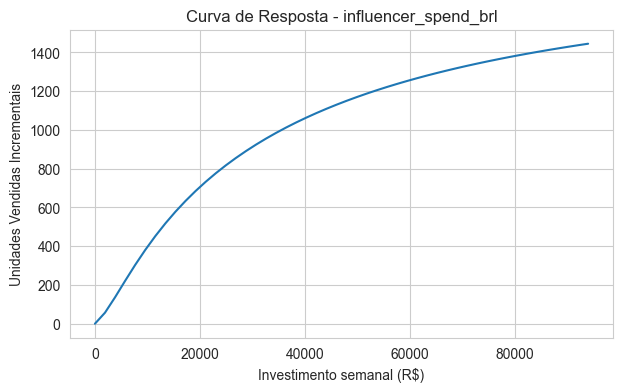

In [96]:
for channel in media_channels:
    fig, ax = plt.subplots(figsize=(7,4))
    spend, response = response_curve(df_adj, df_val, baseline_model, channel)
    ax = plot_response_curve(spend, response, channel, ax)


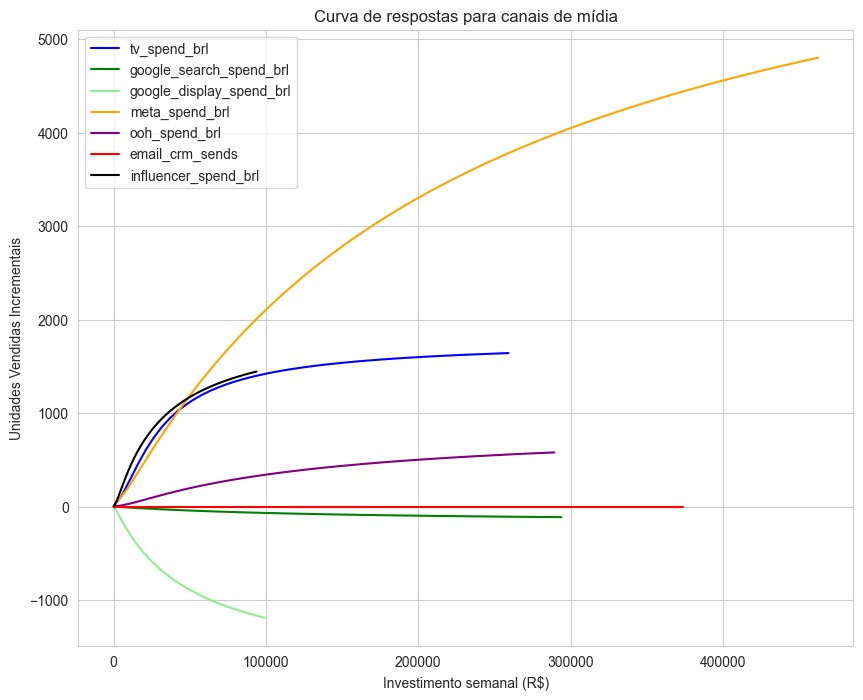

In [227]:
fig, ax = plt.subplots(figsize=(10,8))
colors = ['blue', 'green', 'lightgreen', 'orange', 'purple', 'red', 'black']  # List of colors for each channel
for i, channel in enumerate(media_channels):
    spend, response = response_curve(df_adj, df_val, baseline_model, channel)
    ax.plot(spend, response, label=channel, color=colors[i])
ax.set_title("Curva de respostas para canais de mídia")
ax.legend(loc="upper left")

ax.set_xlabel("Investimento semanal (R$)")
ax.set_ylabel("Unidades Vendidas Incrementais")
plt.show()


OBS: `email_crm_sends` está com a unidade de e-mails enviados e não com gastos em reais.

### 7.3 - ROI por Canal

In [97]:
# Para corrigir o ROI do canal de CRM, vamos assumir um custo médio por envio (CPM) e calcular o gasto total com base no número de envios.
email_cpm = 10/1000  # Supondo 10R$ por 1.000 emails

avg_price = df_val['avg_price_brl'].mean()

roi = {}

for channel in media_channels:
    units_inc = contributions_val[channel].sum()
    revenue_inc = units_inc * avg_price
    spend = df_val[channel].sum()

    if channel == 'email_crm_sends':
        spend = spend * email_cpm

    roi[channel] = revenue_inc / spend

roi_df = pd.DataFrame.from_dict(roi, orient='index', columns=['ROI'])
roi_df.sort_values('ROI', ascending=False)

,ROI
email_crm_sends,404.313296
influencer_spend_brl,5.736138
meta_spend_brl,5.034010
tv_spend_brl,1.463509
ooh_spend_brl,0.844004
google_search_spend_brl,-0.182199
google_display_spend_brl,-5.596482


Os ROIs estimados apresentam sinais e magnitudes coerentes com o papel econômico de cada canal no mix de mídia. O canal de Email/CRM se destaca com ROI extremamente elevado, refletindo seu baixo custo marginal e alta eficiência, embora com menor escalabilidade.

Canais como Influencer, Meta e TV apresentam ROIs positivos e consistentes, indicando capacidade de geração de demanda incremental de forma eficiente. Por outro lado, canais como OOH e Google Search apresentam retorno marginal mais baixo, sugerindo papel complementar no mix como canal de captura. Já o Google Display apresenta ROI negativo, o que indica ausência de incrementalidade isolada e possível redistribuição de conversões capturadas por outros canais, resultado coerente com os coeficientes estimados no modelo.

## 8 - Seleção de Variáveis como Stress Test Causal

O objetivo desta etapa não é maximizar métricas preditivas como WAPE, mas testar a robustez causal do baseline de MMM. <br>
Cada variável adicional é avaliada como um teste de estresse que verifica se ela melhora o ajuste sem distorcer a interpretação econômica e causal dos coeficientes de mídia. <br>
Em casos onde há trade-off entre ajuste estatístico e identificação causal, prioriza-se a coerência causal.

### 8.1 - Metodologia

Para cada variável candidata à inclusão, foi estimado um novo modelo mantendo:

- Mesmo target (units_sold_adj)
- Mesmas transformações de adstock e saturação
- Mesmo split temporal (OOT)

Em cada teste, avaliou-se:

- Impacto no erro fora da amostra (WAPE)
- Alteração no sinal e magnitude dos coeficientes de mídia
- Estabilidade dos parâmetros
- Interpretação causal da variável testada

In [98]:
drop_features

['affiliate_commission_brl',
 'coupons_redeemed',
 'website_sessions',
 'leads_generated']

In [243]:
def calculate_wape(candidate):
    X_test = X.join(df[candidate])
    X_test = add_constant(X_test)

    model_test = OLS(y, X_test).fit()
    X_val = df_val[media_features + control_features]
    X_val = X_val.join(df[candidate])
    X_val = add_constant(X_val)

    y_pred_val = predict_mmm_model(model_test, X_val)

    wape_val_test = np.abs(y_val - y_pred_val).sum() / y_val.sum()

    print(f"WAPE de validação sem adição de variáveis: {100 * wape_val:.3f}%")
    print(f"WAPE com {candidate}: {100 * wape_val_test:.3f}%")
    var_wape = wape_val_test - wape_val
    print(f"Houve uma variação de {100 * var_wape:.5f} p.p.")
    return wape_val_test, model_test

In [230]:
def impact_contribuition(model_test):
    media_coef_test = {}
    for channel in media_channels:
        media_coef_test[channel] = model_test.params[f"{channel}_sat"]
        
    df_media_coef_test = pd.DataFrame({'media_channels':media_coef_test.keys(), 'media_coefs_test':media_coef_test.values()})
    df_result = pd.merge(df_media_coef, df_media_coef_test, on='media_channels')
    df_result['perc_var'] = 100*(df_result['media_coefs_test'] - df_result['media_coefs'])/np.abs(df_result['media_coefs'])
    
    print(df_result)

### 8.2 - Teste de `affiliate_commission_brl`

In [244]:
wape_val_test, model_test = calculate_wape("affiliate_commission_brl")

WAPE de validação sem adição de variáveis: 3.267%
WAPE com affiliate_commission_brl: 3.224%
Houve uma variação de -0.04325 p.p.


In [231]:
impact_contribuition(model_test)

             media_channels  media_coefs  media_coefs_test   perc_var
0              tv_spend_brl  1794.959210       1763.848715  -1.733215
1   google_search_spend_brl  -170.951082       -195.449631 -14.330737
2  google_display_spend_brl -1788.549225      -1703.164344   4.773974
3            meta_spend_brl  7262.017940       7280.927190   0.260386
4             ooh_spend_brl   871.733586        809.409171  -7.149480
5           email_crm_sends     0.007584          0.007404  -2.364447
6      influencer_spend_brl  1942.479155       1881.381416  -3.145348


**Conclusão**: <br>

A inclusão de `affiliate_commission_brl` resultou em leve melhora do WAPE fora da amostra (−0.04325 p.p.), porém provocou redução sistemática nos coeficientes de mídia, especialmente em canais de performance como Google Search (−14%) e OOH (−7%).
Esse comportamento é consistente com endogeneidade estrutural: a comissão de afiliados é consequência direta da venda, não uma causa independente de demanda. Sua inclusão melhora artificialmente o ajuste ao capturar informação contemporânea ao target, mas distorce a atribuição causal dos canais de mídia. <br>
Decisão: manter a variável excluída do modelo final, priorizando coerência causal em detrimento de ganhos marginais de erro.

### 8.3 - Teste de `coupons_redeemed`

In [245]:
wape_val_test, model_test = calculate_wape("coupons_redeemed")

WAPE de validação sem adição de variáveis: 3.267%
WAPE com coupons_redeemed: 3.268%
Houve uma variação de 0.00110 p.p.


In [233]:
impact_contribuition(model_test)

             media_channels  media_coefs  media_coefs_test  perc_var
0              tv_spend_brl  1794.959210       1798.262323  0.184022
1   google_search_spend_brl  -170.951082       -165.298968  3.306276
2  google_display_spend_brl -1788.549225      -1790.252795 -0.095249
3            meta_spend_brl  7262.017940       7257.586850 -0.061017
4             ooh_spend_brl   871.733586        867.873829 -0.442768
5           email_crm_sends     0.007584          0.007538 -0.602552
6      influencer_spend_brl  1942.479155       1942.479512  0.000018


**Conclusão**: <br>

A inclusão de `coupons_redeemed` não produziu melhora no erro fora da amostra, nem alterou de forma relevante os coeficientes dos canais de mídia.
Esse resultado indica que a informação contida no uso de cupons já é capturada por outras variáveis do modelo, como preço médio e eventos promocionais (Black Friday). Além disso, por representar uma ação aplicada no momento da transação, coupons_redeemed não constitui um driver causal independente de demanda. <br>
Decisão: manter a variável fora do modelo final por redundância informacional e ausência de ganho causal.

### 8.4 - Teste `website_sessions`

In [247]:
wape_val_test, model_test = calculate_wape("website_sessions")

WAPE de validação sem adição de variáveis: 3.267%
WAPE com website_sessions: 3.271%
Houve uma variação de 0.00336 p.p.


In [235]:
impact_contribuition(model_test)

             media_channels  media_coefs  media_coefs_test    perc_var
0              tv_spend_brl  1794.959210       1766.356187   -1.593519
1   google_search_spend_brl  -170.951082       -377.928138 -121.073850
2  google_display_spend_brl -1788.549225      -1769.598745    1.059545
3            meta_spend_brl  7262.017940       7063.083966   -2.739376
4             ooh_spend_brl   871.733586        844.460889   -3.128559
5           email_crm_sends     0.007584          0.007436   -1.951969
6      influencer_spend_brl  1942.479155       1934.129253   -0.429858


**Conclusão**: <br>

A inclusão de `website_sessions` não trouxe melhora no erro fora da amostra e provocou distorção significativa nos coeficientes de mídia, especialmente em Google Search (−121%).
Esse comportamento confirma `website_sessions` como uma variável mediadora na cadeia causal Mídia → Sessões → Vendas. Sua inclusão faz com que o modelo atribua parte do efeito causal da mídia à variável intermediária, resultando em subestimação dos ROIs e perda de interpretabilidade econômica. <br>
Decisão: manter `website_sessions` excluída do modelo final para preservar a correta identificação causal dos canais de mídia.

### 8.5 - Teste `leads_generated`

In [246]:
wape_val_test, model_test = calculate_wape("leads_generated")

WAPE de validação sem adição de variáveis: 3.267%
WAPE com leads_generated: 3.393%
Houve uma variação de 0.12522 p.p.


In [237]:
impact_contribuition(model_test)

             media_channels  media_coefs  media_coefs_test     perc_var
0              tv_spend_brl  1794.959210       1866.679118     3.995629
1   google_search_spend_brl  -170.951082       1822.102150  1165.861725
2  google_display_spend_brl -1788.549225      -1858.511986    -3.911705
3            meta_spend_brl  7262.017940       9315.890482    28.282394
4             ooh_spend_brl   871.733586        894.347761     2.594161
5           email_crm_sends     0.007584          0.007666     1.090612
6      influencer_spend_brl  1942.479155       1948.842406     0.327584


**Conclusão**: <br>

A inclusão de `leads_generated` piorou o erro fora da amostra e provocou instabilidade severa nos coeficientes de mídia, com aumentos expressivos em canais digitais como Google Search (+1165%) e Meta (+28%).
Esse comportamento confirma `leads_generated` como uma variável mediadora na cadeia causal Mídia → Leads → Vendas. Sua inclusão faz com que o modelo atribua mérito incremental às mídias por resultados intermediários já capturados, inflando artificialmente os coeficientes e inviabilizando a interpretação de ROI. <br>
Decisão: manter `leads_generated` excluída do modelo final para preservar a identificação causal correta.

### 8.6 - Conclusão sobre a utilização das Variáveis

A tabela abaixo consolida os resultados dos testes de estresse realizados, comparando
impacto preditivo (WAPE em validação) e impacto causal (estabilidade dos coeficientes de mídia).
As decisões priorizam coerência causal e interpretabilidade econômica do MMM.

| Variável Testada              | Impacto no WAPE (Validação) | Impacto nos Coeficientes de Mídia | Diagnóstico Causal              | Decisão Final |
|------------------------------|-----------------------------|-----------------------------------|--------------------------------|---------------|
| affiliate_commission_brl     | Diminuiu levemente          | Redução sistemática dos coeficientes (Search, OOH) | Endogeneidade por simultaneidade (consequência da venda) | Excluir |
| coupons_redeemed             | Neutro                      | Coeficientes praticamente inalterados | Redundância informacional (consequência de venda) | Excluir |
| website_sessions             | Neutro / Leve piora         | Forte viés de mediação (Search −121%) | Variável mediadora (Mídia → Sessões → Vendas) | Excluir |
| leads_generated              | Piorou                      | Instabilidade forte (Search +1165%, Meta +28%) | Mediação grave e inflação artificial de coeficientes | Excluir |

**Conclusão:**  
Apesar de algumas variáveis apresentarem melhora marginal de erro ou neutralidade preditiva,
todas as variáveis testadas nesta etapa introduzem viés de mediação, endogeneidade ou redundância
informacional. Portanto, são excluídas do modelo final, preservando a correta identificação causal
dos efeitos de mídia e a utilidade do MMM para tomada de decisão.

## 9 - Evoluções do Modelo

O modelo baseline frequentista cumpre bem o papel de:
- Validar hipóteses causais
- Garantir interpretabilidade
- Fornecer estimativas causais coerentes dos efeitos de mídia / Estabelecer um ponto de partida estável

Como evolução natural desse trabalho, um próximo passo relevante seria a construção de um **modelo desafiante Bayesiano**, utilizando PyMC, com foco na calibração probabilística dos parâmetros de adstock e saturação.

No modelo atual, os parâmetros de adstock (λ) e de saturação (K, n) foram definidos de forma fixa, com base em conhecimento prévio de MMM e evidências da EDA. Embora essa abordagem seja adequada para um baseline causal simples, ela impõe hipóteses pontuais que não explicitam o grau de incerteza associado a cada transformação.

Um modelo Bayesiano permitiria tratar esses parâmetros como **variáveis aleatórias**, estimando distribuições a posteriori para cada um deles, em vez de valores pontuais. Em particular:
- **Parâmetros de adstock (λ)** poderiam ser inferidos diretamente dos dados, com **intervalos de credibilidade**, permitindo avaliar quão curta ou longa é a memória publicitária de cada canal.
- **Parâmetros de saturação (K e n)** poderiam ser calibrados de forma conjunta ao modelo, capturando não apenas o ponto médio de saturação, mas também a incerteza sobre retornos decrescentes.
- Os **coeficientes de mídia** passariam a ter distribuições completas, reforçando a análise de risco na tomada de decisão (ex.: probabilidade do ROI ser positivo).

## 10 - Conclusão e Recomendações

O modelo de MMM desenvolvido apresentou um excelente ajuste e capacidade preditiva, com um WAPE (Weighted Absolute Percentage Error) de ~3,2% no dataset de validação. Mais importante do que a precisão, o modelo priorizou a identificação causal, permitindo isolar o efeito incremental real de cada canal de mídia. 

Os principais achados indicam:
- Canais de Alta Performance Incremental: Meta Ads e Influenciadores consolidaram-se como os principais motores de novas vendas. Meta apresenta um ROI robusto (aprox. 5.0 a 5.9) e alta contribuição em volume.
- Eficiência Extrema do CRM: O canal de Email/CRM apresentou um ROI desproporcionalmente alto (>400) devido ao seu custo marginal desprezível. No entanto, sua capacidade é limitada pela base de clientes e atua mais como um suporte de conversão do que como gerador de nova demanda.
- O Papel da TV: A TV gera um volume incremental relevante com um ROI positivo (aprox. 1.4 a 2.9), confirmando seu papel na construção de base e alcance.
- Canais de Captura vs. Criação: O Google Search e o Google Display apresentaram contribuições marginais negativas no modelo. Isso sugere que eles atuam majoritariamente como canais de captura de demanda já existente (gerada por outros meios ou orgânica) e não estão criando vendas incrementais nas margens atuais de investimento.
- Eventos Exógenos: A Black Friday é o fator estrutural de maior impacto, gerando um "lift" médio de 16% a 21% nas vendas, o que exige um planejamento de estoque e logística coordenado com o marketing.

---
### Recomendações para o CMO
Com o objetivo de otimizar o orçamento para o próximo ciclo fiscal, recomendam-se as seguintes ações:
1. Realocação de Verba para Escala:
    - Migrar investimentos do Google Display e OOH para Meta Ads e Influenciadores. Meta ainda possui margem para crescimento antes da saturação total, conforme as curvas de resposta.
    - Reduzir o orçamento de OOH, que apresentou ROI pouco menor que 1 (quase neutro), mantendo-o apenas para objetivos de marca (branding) em praças específicas.
2. Revisão da Estratégia de Google Search:
    - O investimento atual em Search parece estar em uma zona de rendimentos decrescentes onde apenas "canibaliza" o tráfego orgânico ou conversões que ocorreriam via Meta/Influenciadores.
    - Recomenda-se realizar um teste de limpeza em Search em algumas categorias para validar se a redução do investimento impacta de fato as vendas totais.
3. Potencialização do CRM e Influenciadores:
    - Dada a alta eficiência do CRM, o foco deve ser em aumentar a base de leads qualificados para permitir maior volume de disparos sem perda de relevância.
    - Manter a aposta em Influenciadores, pois é o canal com menor colinearidade com os demais, indicando que atinge audiências únicas.
4. Atenção à Elasticidade de Preço:
    - O modelo confirmou uma relação negativa consistente entre preço médio e vendas. Estratégias de marketing agressivas podem ser anuladas por aumentos de preço não coordenados. É vital manter o alinhamento entre as campanhas de mídia e a política de precificação.
5. Próximos Passos em Dados:
    - Investir em dados de investimento de concorrentes mais granulares, pois a pressão competitiva mostrou-se um controle relevante no modelo.
    - Aprimorar a coleta de dados de distribuição geográfica para permitir um MMM regionalizado, capturando diferenças de comportamento entre estados.